# Thesis Experiment Analysis: Skill Extraction Task

This notebook provides a comprehensive analysis of the skill extraction task experiment results, including:
- Bar plots for each prompt technique grouped by LLM model
- Line graphs for metric trends across prompt techniques
- Radar charts for latency comparison across models and prompts
- Overall performance plots for the entire skill extraction task
- Heatmaps, box plots, and ranking tables for deeper insights

**Dataset**: `Final_Thesis_Experiment_Results_Skills.xlsx` (Sheet: `Task 2 Skill Extraction`)

## 1. Setup and Dependencies

In [ ]:
!pip install openpyxl matplotlib seaborn pandas numpy --quiet

In [ ]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading and Preprocessing

In [ ]:
# ── Upload the file in Colab or adjust the path for local use ──
from google.colab import files
uploaded = files.upload()

FILE_PATH  = "Final_Thesis_Experiment_Results_Skills.xlsx"
SHEET_NAME = "Task 2 Skill Extraction "   # note trailing space

raw_df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

# Rename model column
raw_df.rename(columns={"LLM Model ": "Model"}, inplace=True)

df = raw_df.copy()
df["Prompting"] = df["Prompting"].str.strip()
df["Model"]     = df["Model"].str.strip()

# Drop rows where Prompting is NaN (blank separator rows)
df = df[df["Prompting"].notna() & (df["Prompting"] != "")].copy()

# Map API model names to clean display labels
MODEL_LABELS = {
    "llama-3.1-8b-instant":    "LLaMA-3.1-8B",
    "llama-3.3-70b-versatile": "LLaMA-3.3-70B",
    "openai/gpt-oss-120b":     "GPT-OSS-120B",
    "openai/gpt-oss-20b":      "GPT-OSS-20B",
    "qwen/qwen3-32b":          "Qwen3-32B",
}
df["Model"] = df["Model"].map(MODEL_LABELS).fillna(df["Model"])

# Derive directly from data — no hardcoding
MODELS  = ["LLaMA-3.1-8B", "LLaMA-3.3-70B", "GPT-OSS-120B", "GPT-OSS-20B", "Qwen3-32B"]
PROMPTS = df["Prompting"].unique().tolist()

# Skill-extraction-specific quality metrics
QUALITY_METRICS = [
    "avg_precision", "avg_recall", "avg_f1",
    "avg_jaccard", "avg_bert_f1", "composite_score",
]
LATENCY_METRICS = ["avg_latency_sec", "min_latency_sec", "max_latency_sec"]
COUNT_METRICS   = ["avg_predicted_count", "avg_gold_count"]

METRIC_LABELS = {
    "avg_precision":       "Precision",
    "avg_recall":          "Recall",
    "avg_f1":              "F1 Score",
    "avg_jaccard":         "Jaccard",
    "avg_bert_f1":         "BERTScore F1",
    "composite_score":     "Composite Score",
    "avg_latency_sec":     "Avg Latency (s)",
    "min_latency_sec":     "Min Latency (s)",
    "max_latency_sec":     "Max Latency (s)",
    "avg_predicted_count": "Predicted Count",
    "avg_gold_count":      "Gold Count",
}

MODEL_COLORS = {
    "LLaMA-3.1-8B":  "#4C72B0",
    "LLaMA-3.3-70B": "#DD8452",
    "GPT-OSS-120B":  "#55A868",
    "GPT-OSS-20B":   "#C44E52",
    "Qwen3-32B":     "#8172B2",
}

# Ensure all metric columns are numeric
for col in QUALITY_METRICS + LATENCY_METRICS + COUNT_METRICS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Shape: {df.shape}")
print(f"\nPrompt techniques ({len(PROMPTS)}):")
for p in PROMPTS: print(f"  {p}")
print(f"\nModels ({len(MODELS)}):")
for m in MODELS: print(f"  {m}")
print(f"\nRows per Model:")
print(df["Model"].value_counts().to_string())
df.head(10)

Saving Final_Thesis_Experiment_Results_Skills.xlsx to Final_Thesis_Experiment_Results_Skills.xlsx
Shape: (40, 16)

Prompt techniques (8):
  Zero shot
  Few Shot
  Instruction
  Role Based
  Chain of Thoughts
  Tree of Thoughts
  ReAct
  Self Consistency

Models (5):
  LLaMA-3.1-8B
  LLaMA-3.3-70B
  GPT-OSS-120B
  GPT-OSS-20B
  Qwen3-32B

Rows per Model:
Model
LLaMA-3.1-8B     8
LLaMA-3.3-70B    8
GPT-OSS-120B     8
GPT-OSS-20B      8
Qwen3-32B        8


,Prompting,Model,temperature,total_samples,avg_precision,avg_recall,avg_f1,avg_jaccard,avg_bert_f1,avg_predicted_count,avg_gold_count,avg_latency_sec,min_latency_sec,max_latency_sec,total_latency_sec,composite_score
0,Zero shot,LLaMA-3.1-8B,0.2,25,0.1586,0.1978,0.1728,0.1035,0.9144,9.36,7.24,0.1831,0.119,0.271,4.578,0.3164
1,Zero shot,LLaMA-3.3-70B,0.2,25,0.1793,0.1774,0.1775,0.1068,0.9082,7.12,7.24,0.2105,0.159,0.297,5.262,0.3169
2,Zero shot,GPT-OSS-120B,0.2,25,0.2736,0.2601,0.2645,0.1663,0.9243,6.84,7.24,0.6618,0.443,0.987,16.546,0.3876
3,Zero shot,GPT-OSS-20B,0.2,25,0.2567,0.2230,0.2365,0.1491,0.9169,6.16,7.24,0.3967,0.219,1.032,9.917,0.3652
4,Zero shot,Qwen3-32B,0.2,25,0.2100,0.2371,0.2220,0.1439,0.9160,7.92,7.24,1.4127,0.658,2.801,35.318,0.3536
5,Few Shot,LLaMA-3.1-8B,0.2,25,0.1391,0.1741,0.1468,0.0859,0.9012,9.36,7.24,0.3172,0.174,0.932,7.929,0.2955
6,Few Shot,LLaMA-3.3-70B,0.2,25,0.1604,0.1672,0.1627,0.1023,0.9046,7.76,7.24,0.3337,0.179,1.663,8.343,0.3055
7,Few Shot,GPT-OSS-120B,0.2,25,0.2220,0.2019,0.2100,0.1270,0.9090,6.64,7.24,0.4759,0.329,0.658,11.898,0.3423
8,Few Shot,GPT-OSS-20B,0.2,25,0.2132,0.1909,0.1995,0.1255,0.9054,6.48,7.24,0.3721,0.273,0.669,9.303,0.3343
9,Few Shot,Qwen3-32B,0.2,25,0.2046,0.2216,0.2106,0.1263,0.9123,7.92,7.24,0.2850,0.203,0.449,7.124,0.3435


## 3. Bar Plots: One Figure per Prompt Technique

**Structure**: Each prompt technique produces one figure.  
**X-axis**: LLM Models.  
**Grouped bars**: Each metric (Precision, Recall, F1, Jaccard, BERTScore F1, Composite Score).  
This mirrors the summarisation style where models are on the x-axis and metrics are the bar groups.

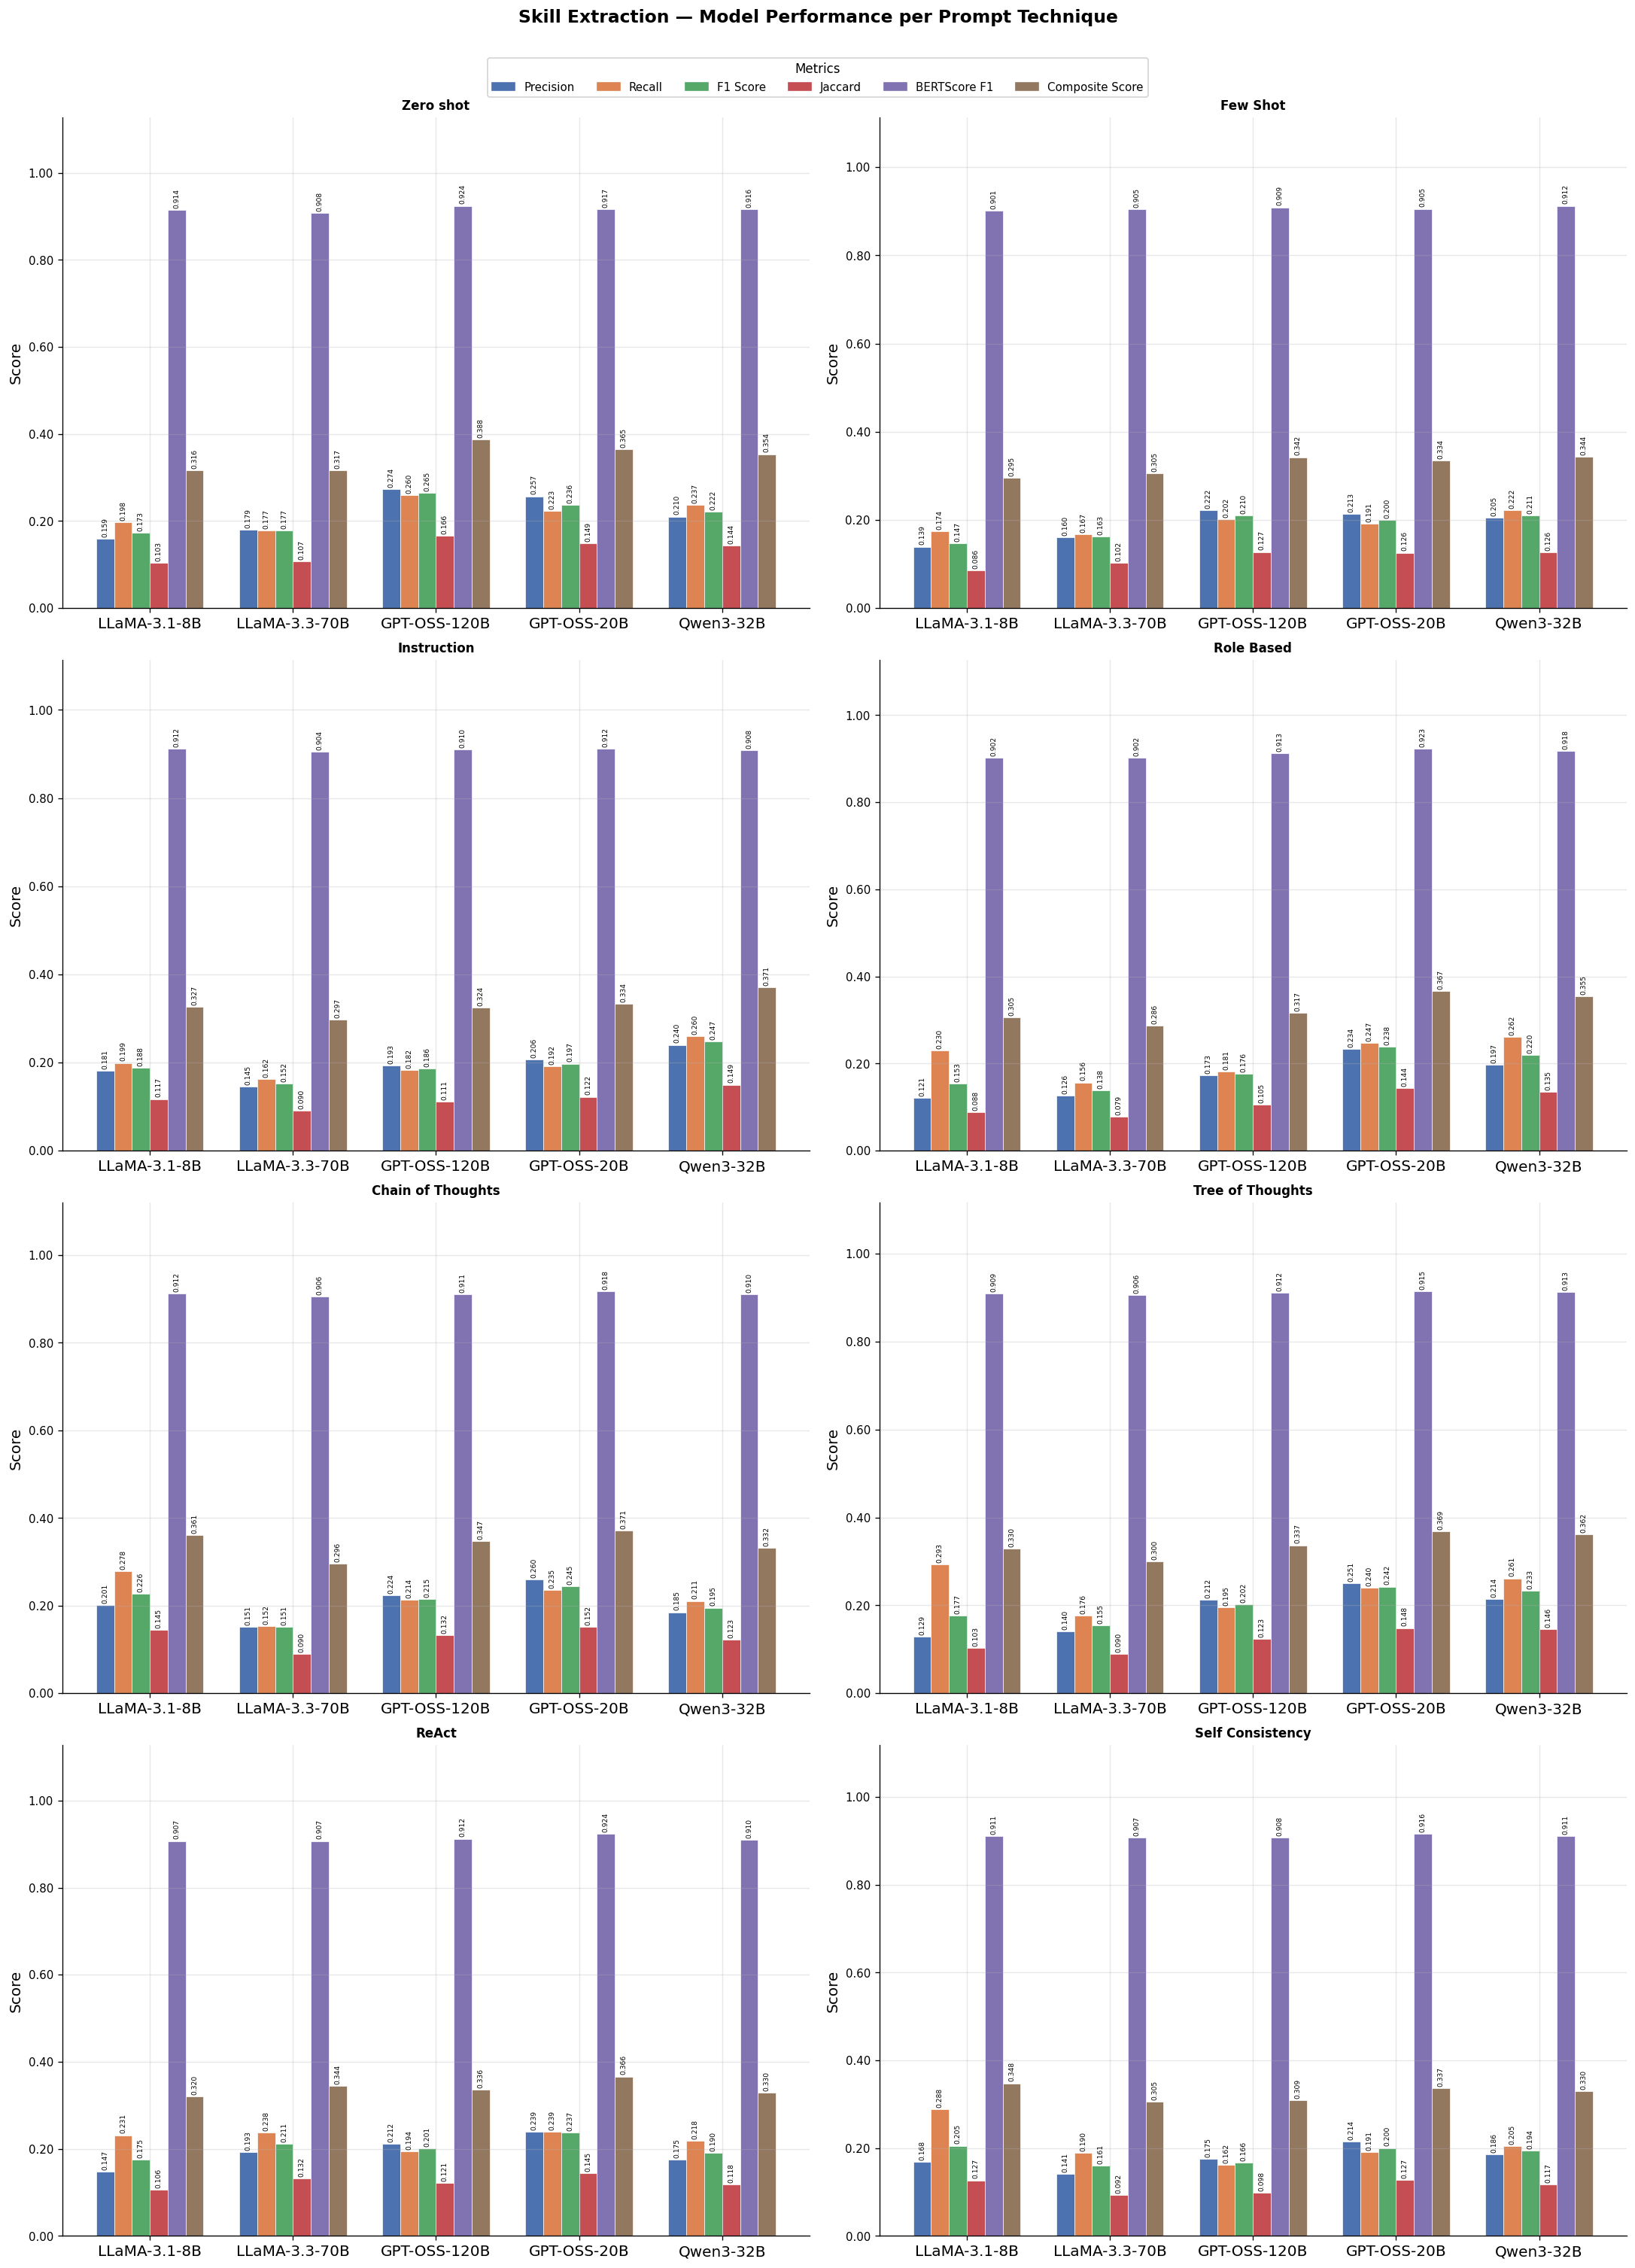

In [ ]:
# ── Colour palette for metrics ───────────────────────────────────────────────
METRIC_COLORS = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B2", "#937860",
]


def plot_prompt_bar(ax, data, prompt, metrics):
    """X-axis = Models, grouped bars = metrics, filtered to one prompt."""
    subset = data[data["Prompting"] == prompt]
    agg = subset.groupby("Model")[metrics].mean().reindex(MODELS)

    n_models  = len(MODELS)
    n_metrics = len(metrics)
    x          = np.arange(n_models)
    bar_w      = 0.75 / n_metrics
    offsets    = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    for i, (metric, color) in enumerate(zip(metrics, METRIC_COLORS)):
        vals = agg[metric].values
        bars = ax.bar(x + offsets[i], vals, width=bar_w,
                      label=METRIC_LABELS.get(metric, metric),
                      color=color, edgecolor="white", linewidth=0.4)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.004, f"{val:.3f}",
                        ha="center", va="bottom", fontsize=5.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=12, ha="center")
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    valid_max = agg[metrics].max().max()
    ax.set_ylim(0, valid_max * 1.22 if not np.isnan(valid_max) else 1)


metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols = 2
n_rows = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    plot_prompt_bar(axes[idx], df, prompt, metrics_to_plot)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

metric_handles = [plt.Rectangle((0, 0), 1, 1, color=METRIC_COLORS[i])
                  for i in range(len(metrics_to_plot))]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(metric_handles, metric_names, loc="upper center",
           ncol=len(metrics_to_plot), fontsize=9,
           bbox_to_anchor=(0.5, 1.02), frameon=True,
           title="Metrics", title_fontsize=10)
fig.suptitle("Skill Extraction — Model Performance per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.04)
plt.savefig("skills_bar_per_prompt.png", bbox_inches="tight")
plt.show()

## 4. Line Graphs: One Figure per Prompt Technique

**Structure**: One figure per prompt technique.  
**X-axis**: LLM Models.  
**Lines**: Each metric is a separate line with markers.  
This shows how each metric varies across models for a given prompt technique.

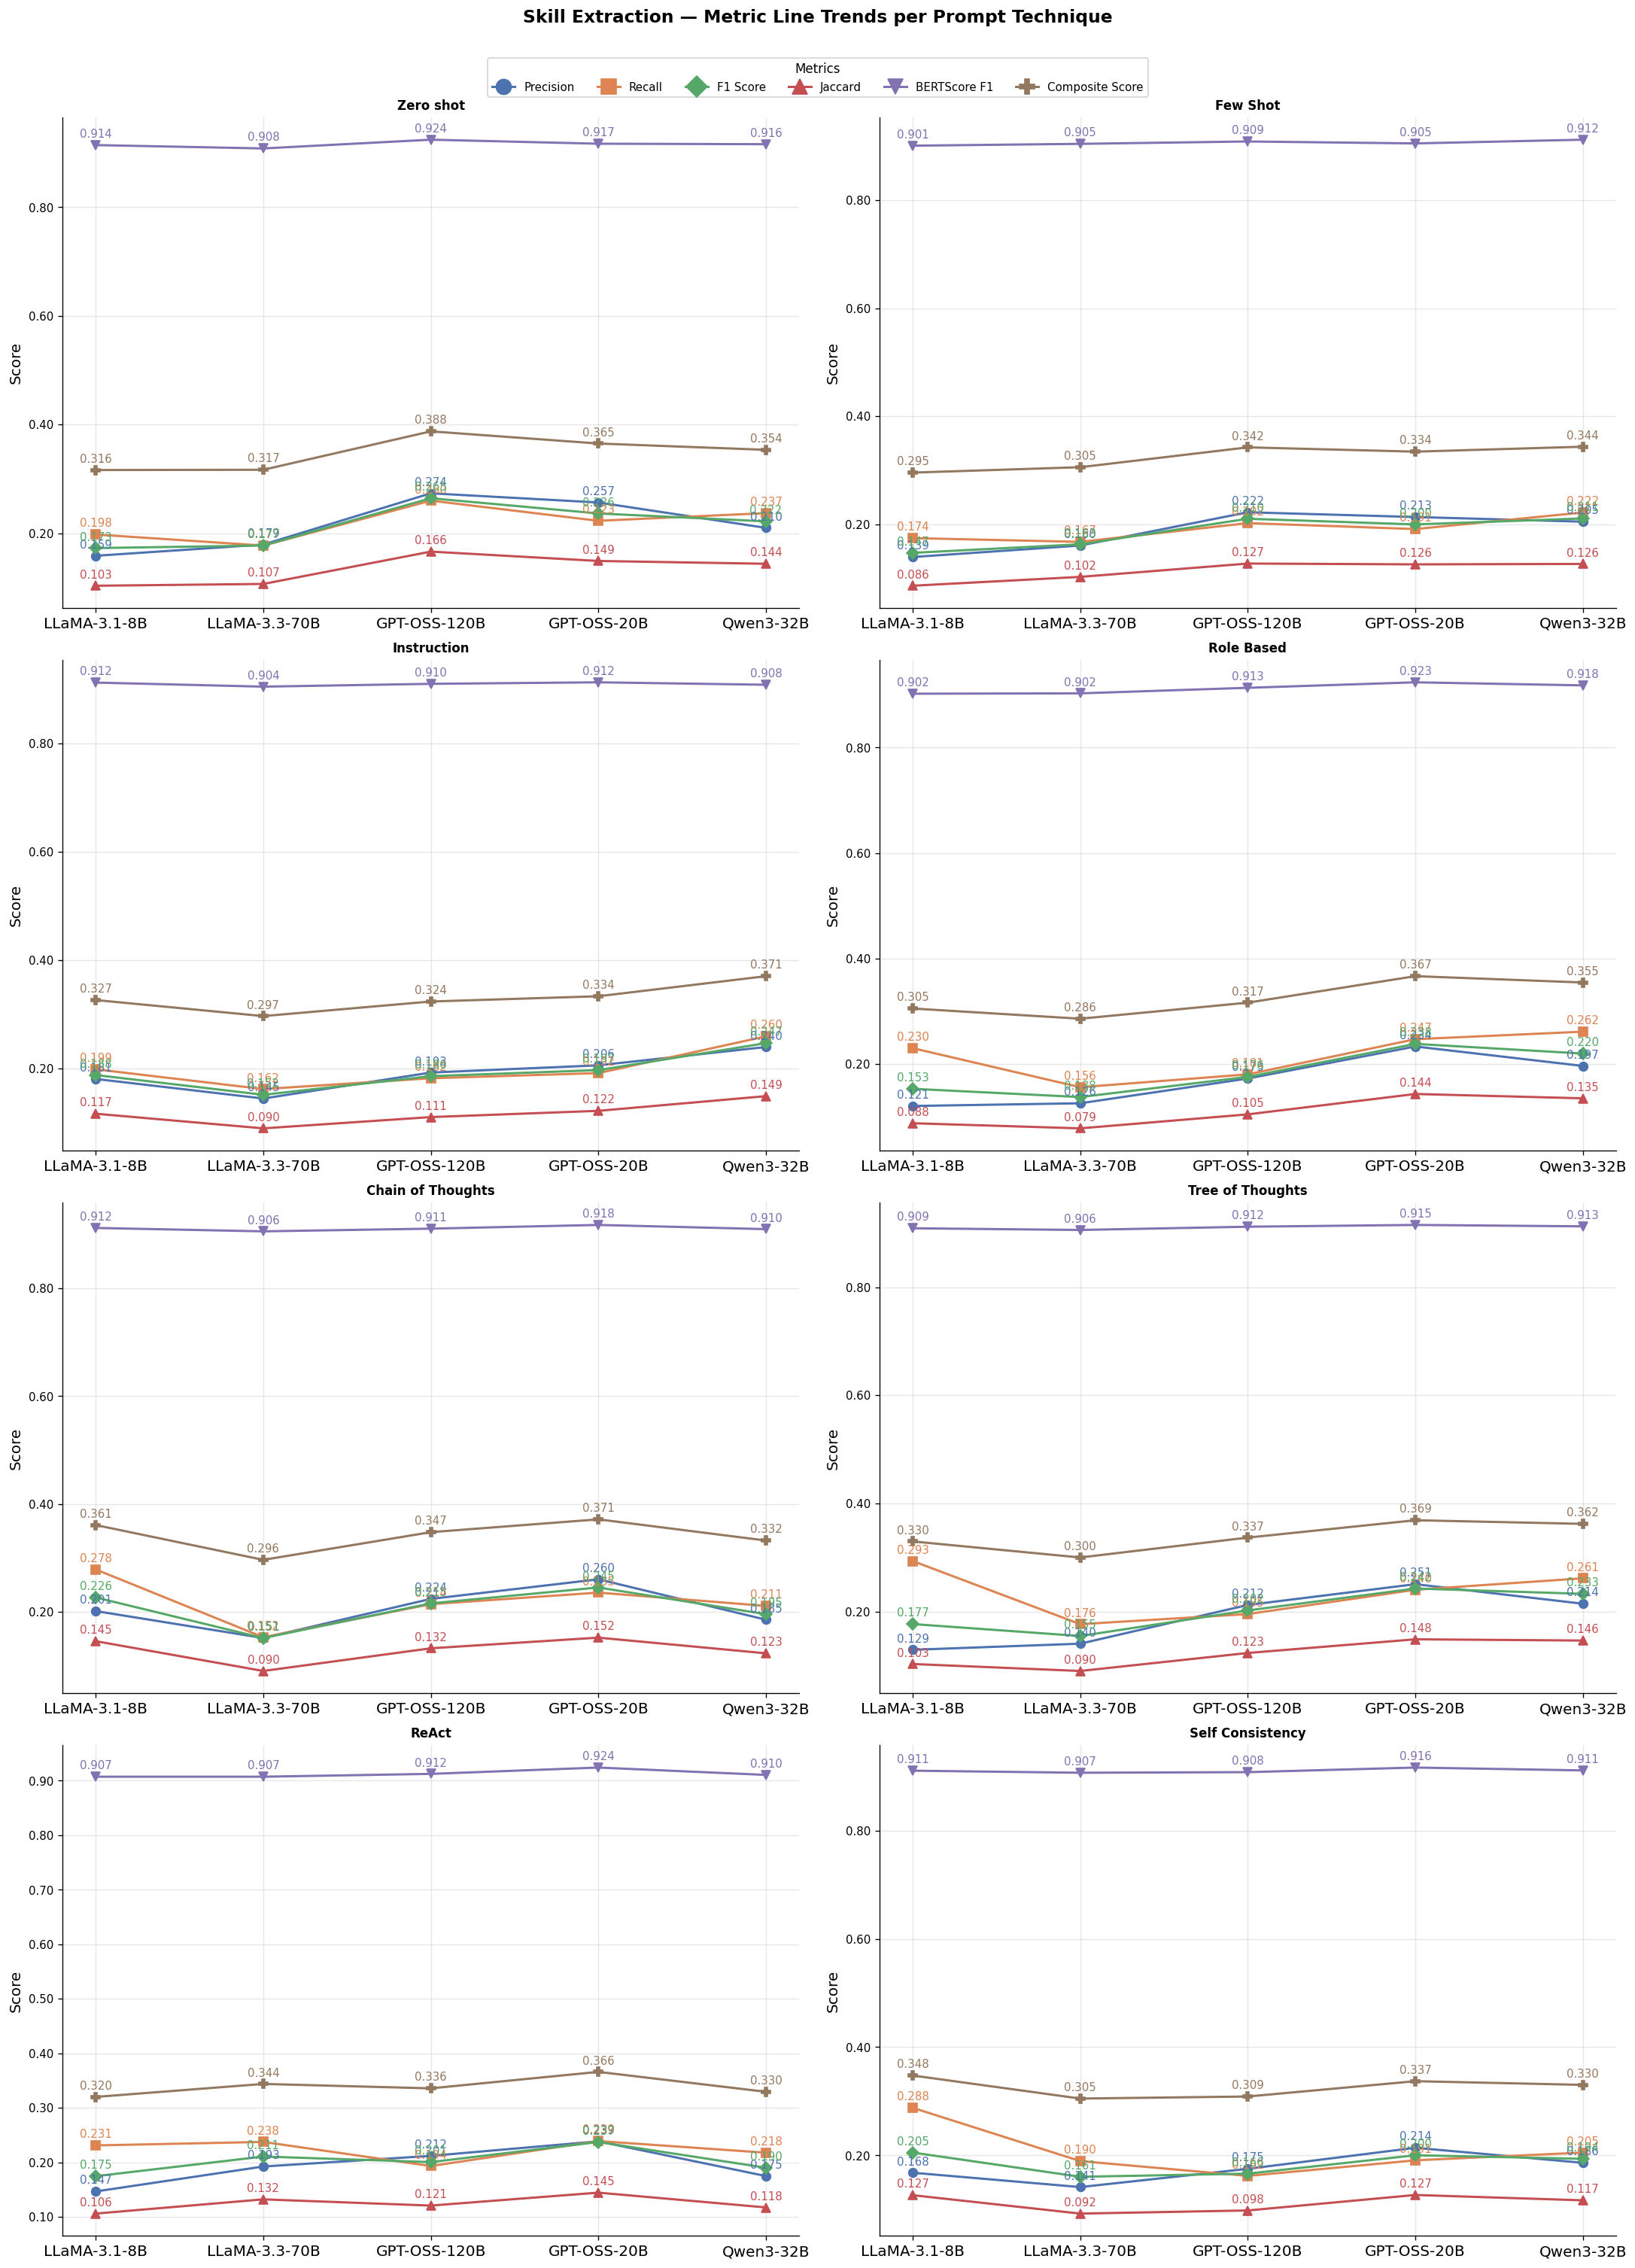

In [ ]:
MARKERS = ["o", "s", "D", "^", "v", "P"]


def plot_prompt_line(ax, data, prompt, metrics):
    """X-axis = Models, one line per metric, filtered to one prompt."""
    subset = data[data["Prompting"] == prompt]
    agg = subset.groupby("Model")[metrics].mean().reindex(MODELS)

    x = np.arange(len(MODELS))
    for i, (metric, color) in enumerate(zip(metrics, METRIC_COLORS)):
        vals = agg[metric].values
        ax.plot(x, vals, marker=MARKERS[i % len(MARKERS)],
                label=METRIC_LABELS.get(metric, metric),
                color=color, linewidth=1.8, markersize=7)
        for xi, val in zip(x, vals):
            if not np.isnan(val):
                ax.annotate(f"{val:.3f}", (xi, val),
                            textcoords="offset points", xytext=(0, 6),
                            ha="center", fontsize=9, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=12, ha="center")
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))


metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols = 2
n_rows = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    plot_prompt_line(axes[idx], df, prompt, metrics_to_plot)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

line_handles = [Line2D([0], [0], color=METRIC_COLORS[i],
                       marker=MARKERS[i % len(MARKERS)],
                       linewidth=1.8, markersize=12)
                for i in range(len(metrics_to_plot))]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(line_handles, metric_names, loc="upper center",
           ncol=len(metrics_to_plot), fontsize=9,
           bbox_to_anchor=(0.5, 1.02), frameon=True,
           title="Metrics", title_fontsize=10)
fig.suptitle("Skill Extraction — Metric Line Trends per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.04)
plt.savefig("skills_line_per_prompt.png", bbox_inches="tight")
plt.show()

## 5. Radar Charts: Latency Profile per Model across Prompt Techniques

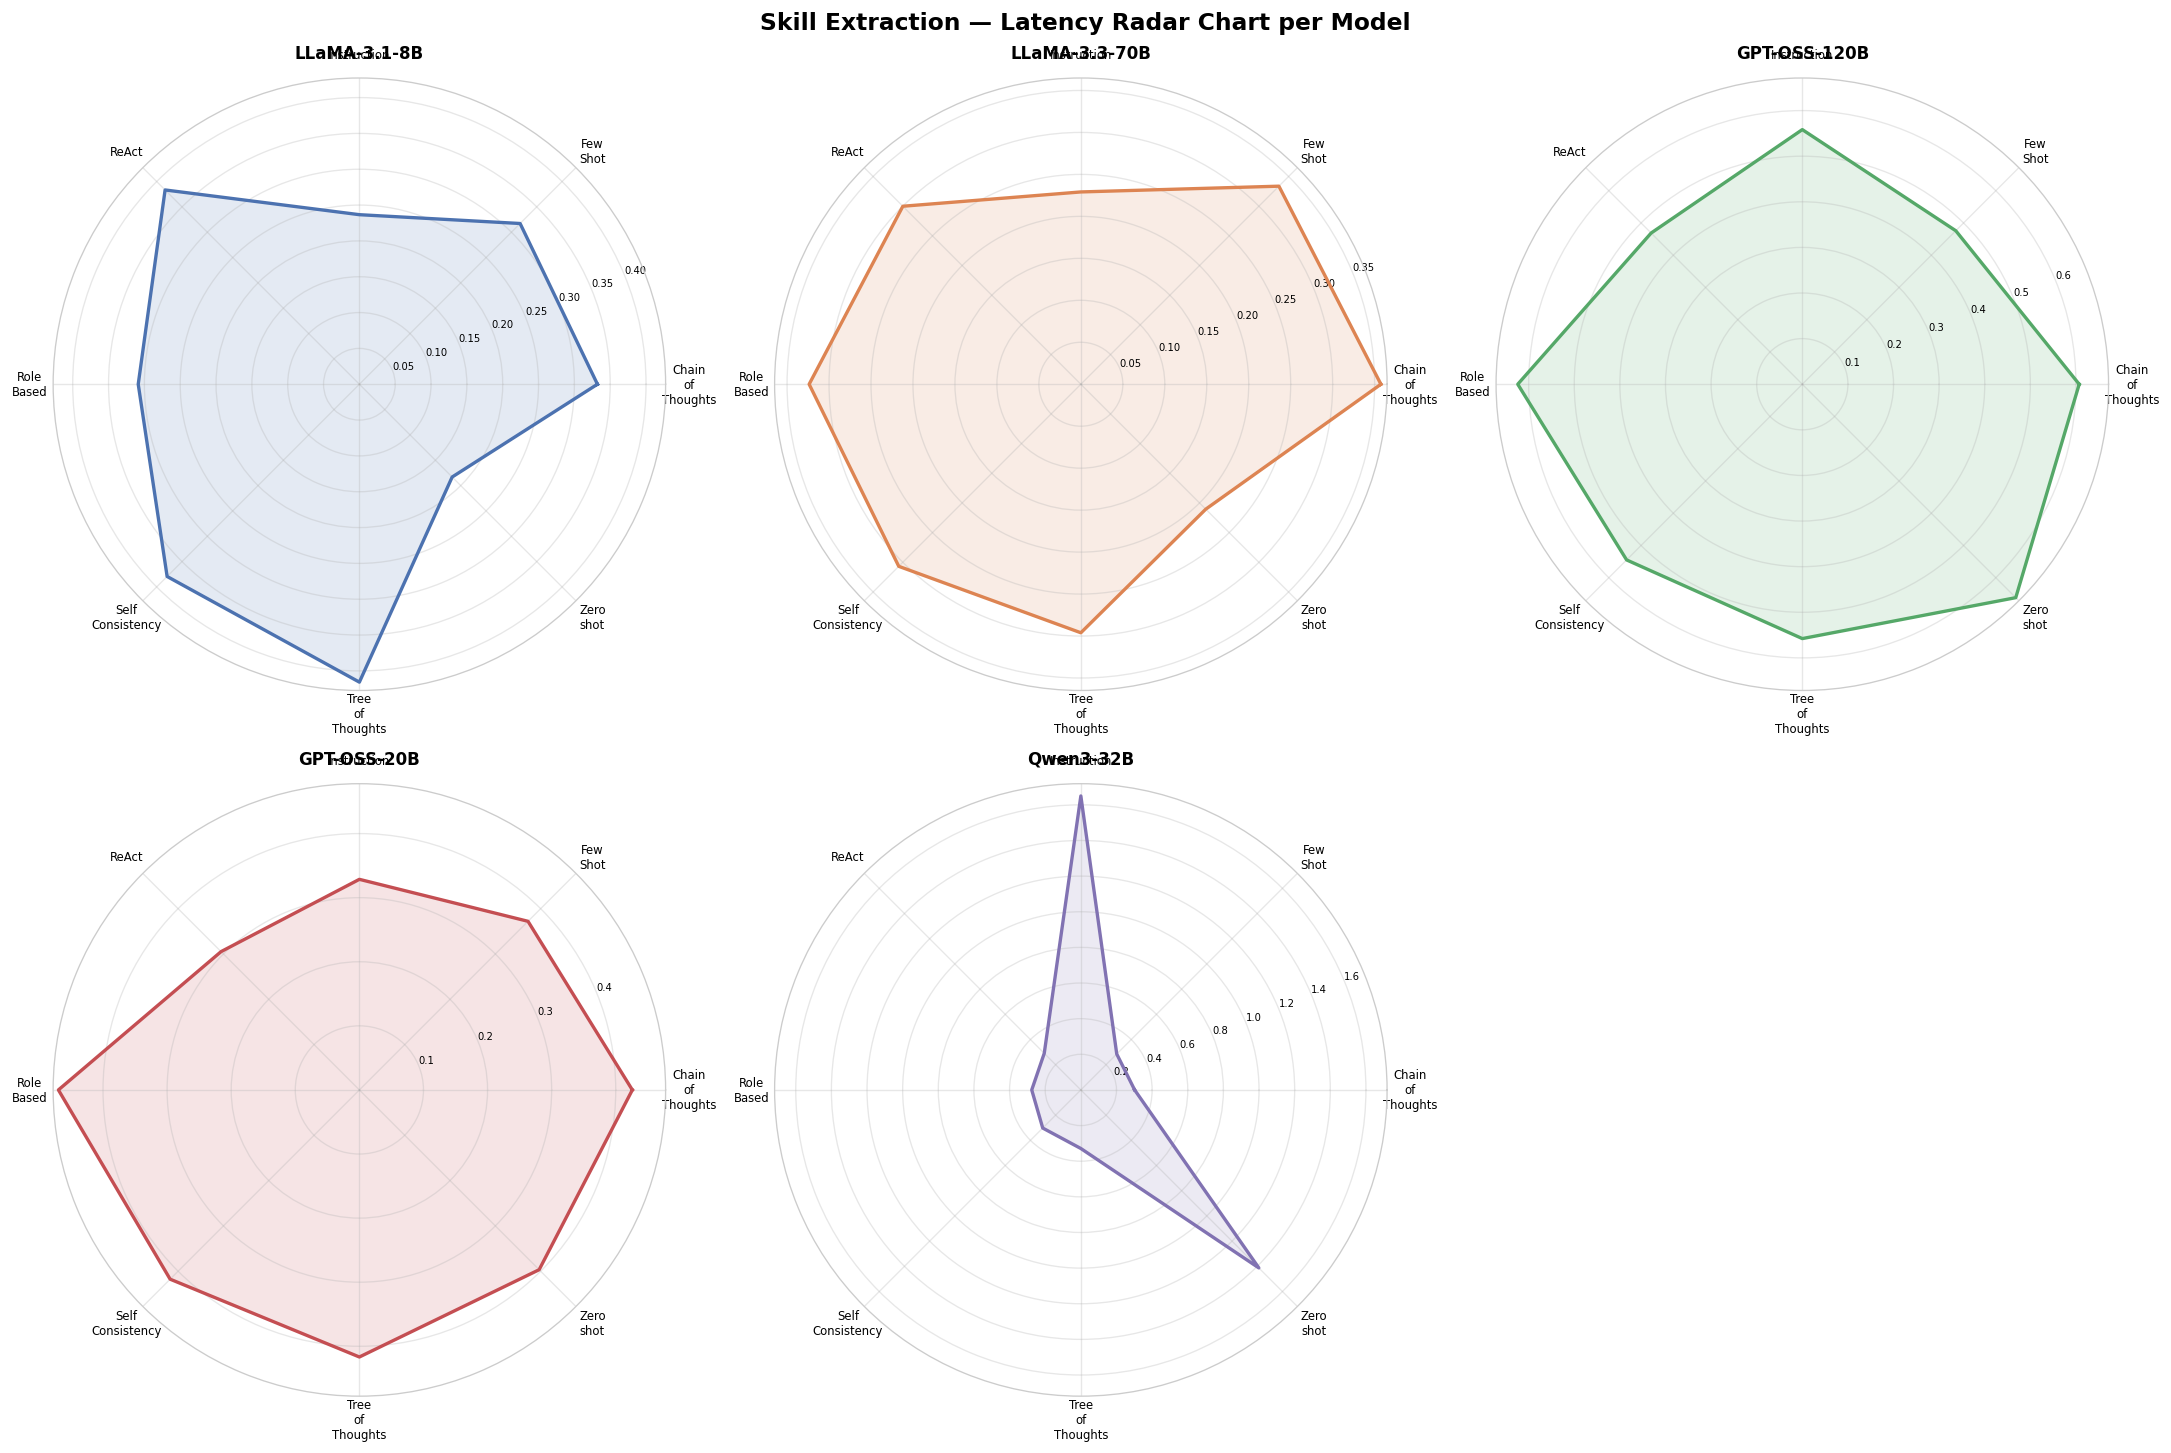

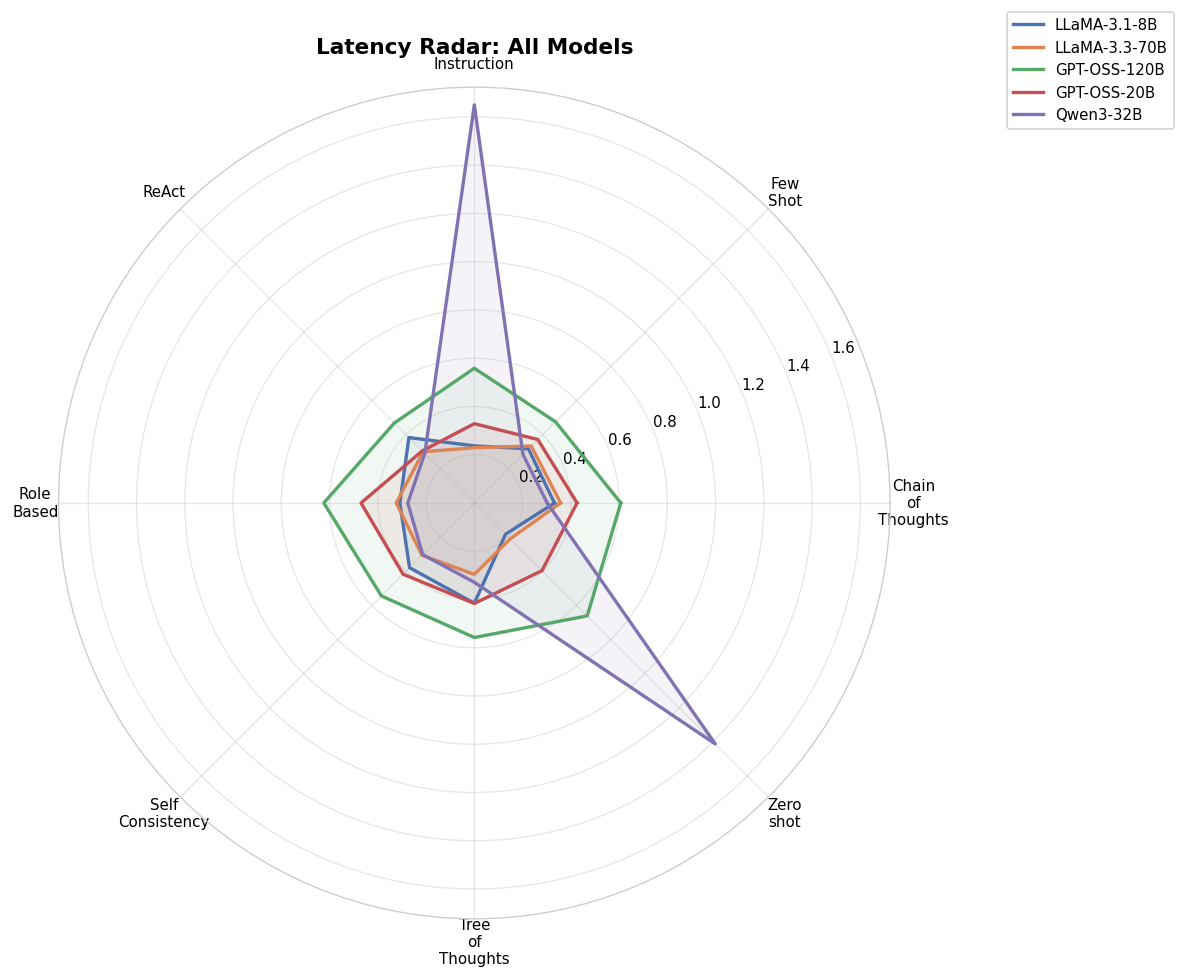

In [ ]:
def make_radar_chart(ax, values, labels, color, model_name, fill_alpha=0.15):
    """Draw a single radar (spider) chart on a polar axis."""
    n = len(labels)
    angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    values_closed = values + [values[0]]
    angles_closed = angles + [angles[0]]

    ax.plot(angles_closed, values_closed, color=color, linewidth=2)
    ax.fill(angles_closed, values_closed, color=color, alpha=fill_alpha)
    ax.set_xticks(angles)
    ax.set_xticklabels([lbl.replace(" ", "\n") for lbl in labels], size=7)
    ax.set_title(model_name, size=10, fontweight="bold", pad=12)
    ax.spines["polar"].set_color("#cccccc")
    ax.yaxis.set_tick_params(labelsize=6)


pivot = (
    df.groupby(["Prompting", "Model"])["avg_latency_sec"]
    .mean()
    .unstack("Model")
    .reindex(columns=MODELS)
)
prompt_labels = pivot.index.tolist()

# Individual radar per model
n_cols = 3
n_rows = int(np.ceil(len(MODELS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows),
                         subplot_kw={"polar": True}, constrained_layout=True)
axes = np.array(axes).flatten()

for i, model in enumerate(MODELS):
    vals  = pivot[model].fillna(0).tolist()
    color = MODEL_COLORS.get(model, "#888888")
    make_radar_chart(axes[i], vals, prompt_labels, color, model)

for idx in range(len(MODELS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Skill Extraction — Latency Radar Chart per Model", fontsize=14, fontweight="bold")
plt.savefig("skills_radar_latency.png", bbox_inches="tight")
plt.show()


# Combined radar — all models overlaid
n  = len(prompt_labels)
angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles_closed = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
for model in MODELS:
    vals        = pivot[model].fillna(0).tolist()
    vals_closed = vals + [vals[0]]
    color       = MODEL_COLORS.get(model, "#888888")
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2, label=model)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.08)

ax.set_xticks(angles)
ax.set_xticklabels([lbl.replace(" ", "\n") for lbl in prompt_labels], size=9)
ax.spines["polar"].set_color("#cccccc")
ax.set_title("Latency Radar: All Models", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.savefig("skills_radar_latency_combined.png", bbox_inches="tight")
plt.show()

## 6. Overall Plots: Entire Skill Extraction Task

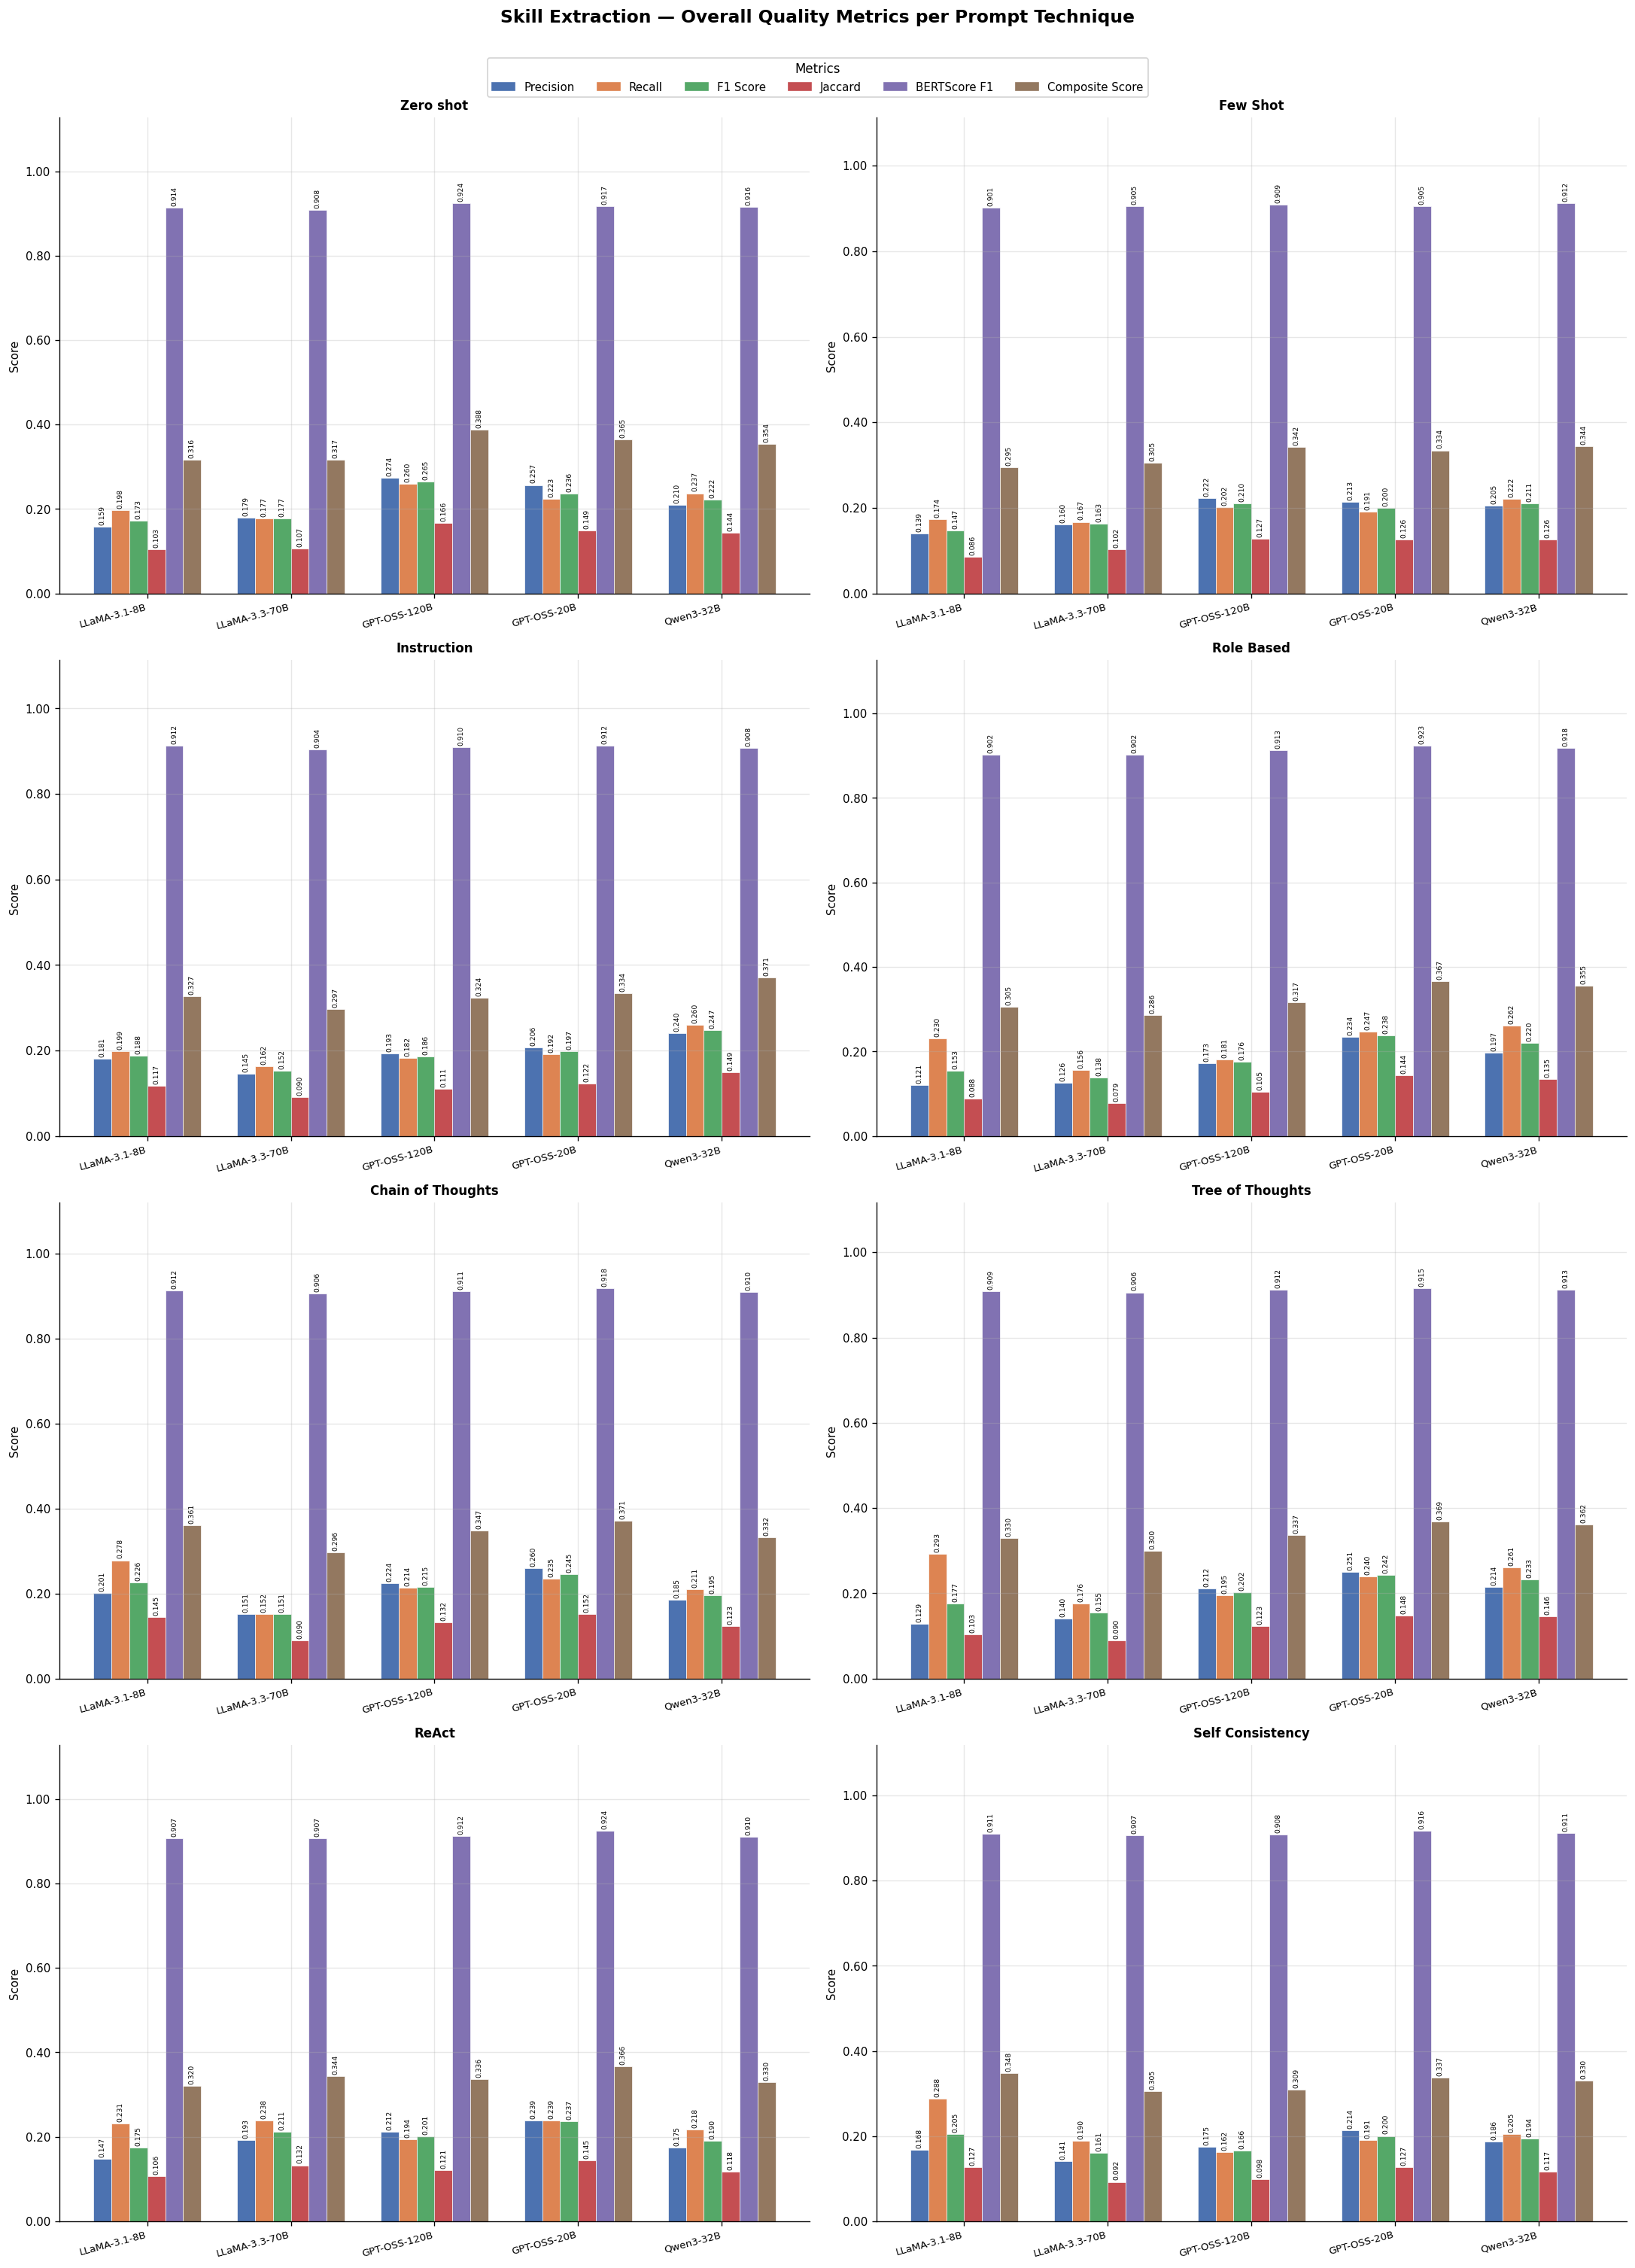

In [ ]:
metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols    = 2
n_rows    = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    ax     = axes[idx]
    subset = df[df["Prompting"] == prompt]
    agg    = subset.groupby("Model")[metrics_to_plot].mean().reindex(MODELS)

    n_models  = len(MODELS)
    n_metrics = len(metrics_to_plot)
    x      = np.arange(n_models)
    bar_w  = 0.75 / n_metrics
    offsets = np.linspace(-(n_metrics-1)/2, (n_metrics-1)/2, n_metrics) * bar_w

    for i, (metric, color) in enumerate(zip(metrics_to_plot, METRIC_COLORS)):
        vals = agg[metric].values
        bars = ax.bar(x + offsets[i], vals, width=bar_w,
                      label=METRIC_LABELS.get(metric, metric),
                      color=color, edgecolor="white", linewidth=0.4)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.004, f"{val:.3f}",
                        ha="center", va="bottom", fontsize=5.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Score", fontsize=9)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    valid_max = agg[metrics_to_plot].max().max()
    ax.set_ylim(0, valid_max * 1.22 if not np.isnan(valid_max) else 1)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

metric_handles = [plt.Rectangle((0, 0), 1, 1, color=METRIC_COLORS[i])
                  for i in range(len(metrics_to_plot))]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(metric_handles, metric_names, loc="upper center",
           ncol=len(metrics_to_plot), fontsize=9,
           bbox_to_anchor=(0.5, 1.02), frameon=True,
           title="Metrics", title_fontsize=10)
fig.suptitle("Skill Extraction — Overall Quality Metrics per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.04)
plt.savefig("skills_overall_quality_bar.png", bbox_inches="tight")
plt.show()

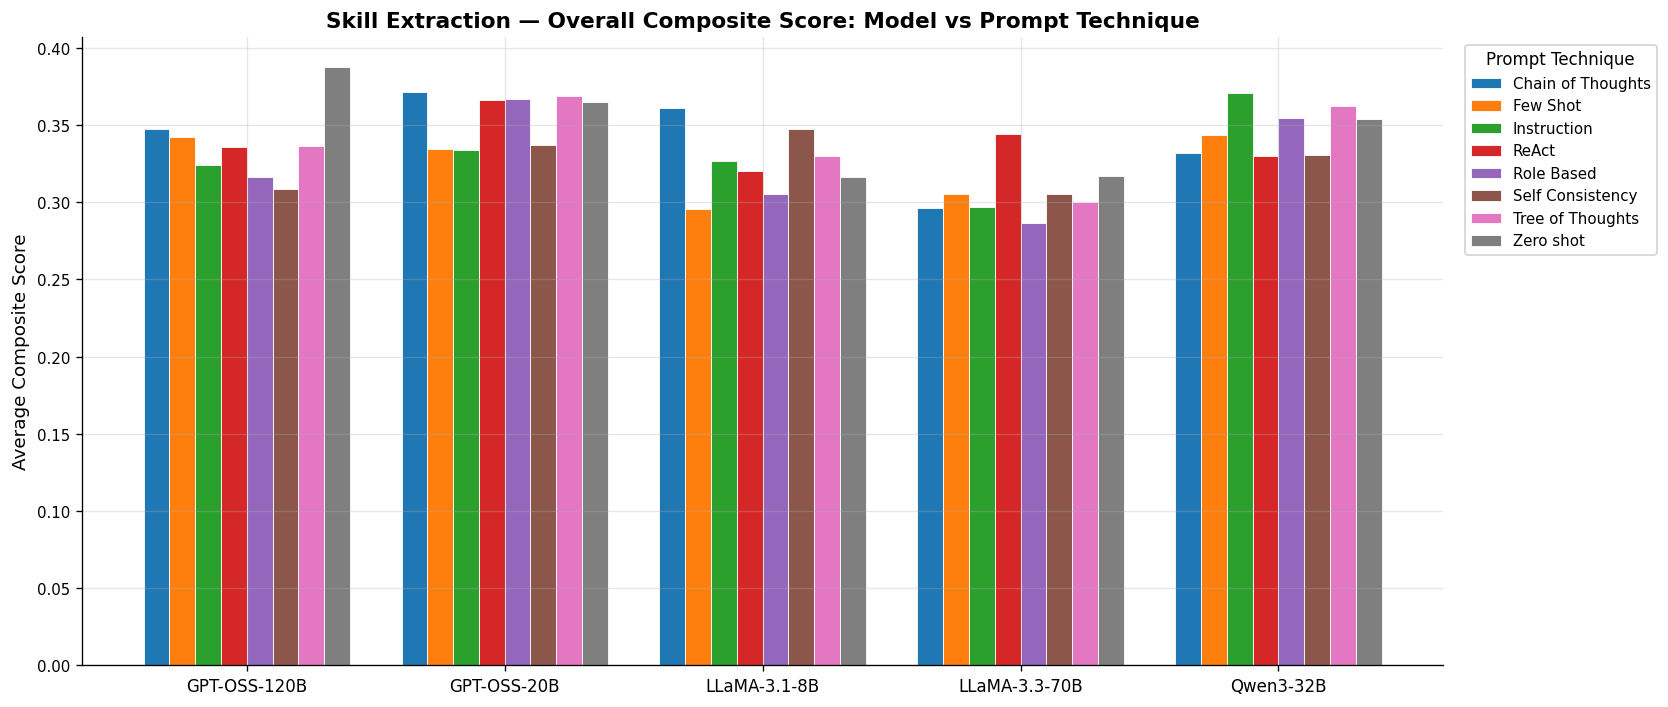

In [ ]:
# ── Overall Composite Score: Model vs Prompt heatmap-style bar ───────────────
comp_pivot = (
    df.groupby(["Model", "Prompting"])["composite_score"]
    .mean()
    .unstack("Prompting")
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comp_pivot))
n_prompts = len(comp_pivot.columns)
width = 0.8 / n_prompts
prompt_colors = sns.color_palette("tab10", n_prompts)

for i, prompt in enumerate(comp_pivot.columns):
    offsets = (i - n_prompts / 2 + 0.5) * width
    ax.bar(
        x + offsets,
        comp_pivot[prompt].values,
        width=width,
        label=prompt,
        color=prompt_colors[i],
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(comp_pivot.index, fontsize=10)
ax.set_ylabel("Average Composite Score", fontsize=11)
ax.set_title(
    "Skill Extraction — Overall Composite Score: Model vs Prompt Technique",
    fontsize=13,
    fontweight="bold",
)
ax.legend(
    title="Prompt Technique",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
)
plt.tight_layout()
plt.savefig("skills_overall_composite_bar.png", bbox_inches="tight")
plt.show()

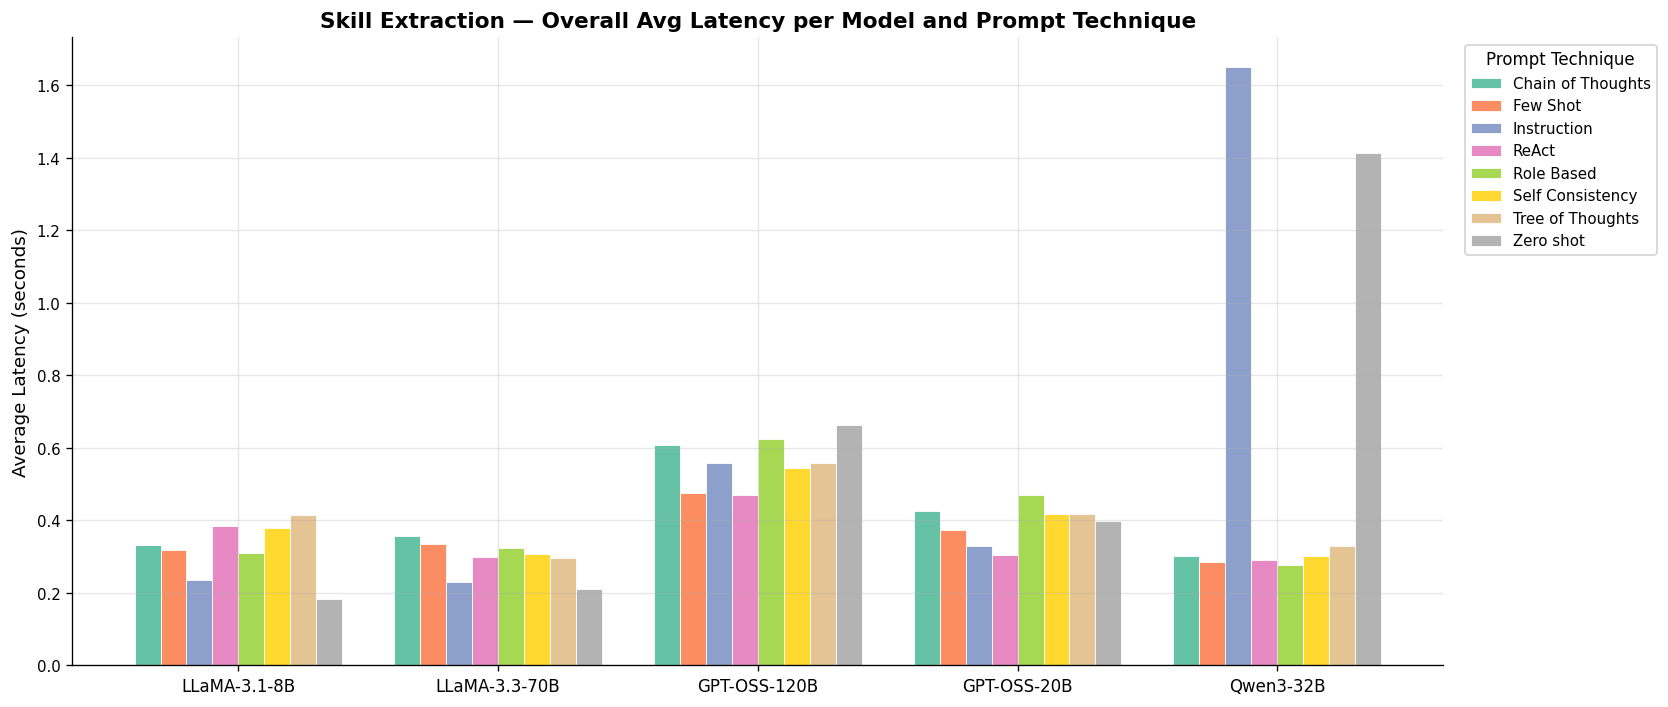

In [ ]:
# ── Overall Latency: bar chart across models and prompts ─────────────────────
lat_pivot = (
    df.groupby(["Model", "Prompting"])["avg_latency_sec"]
    .mean()
    .unstack("Prompting")
    .reindex(MODELS)
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(lat_pivot))
n_prompts = len(lat_pivot.columns)
width = 0.8 / n_prompts
lat_colors = sns.color_palette("Set2", n_prompts)

for i, prompt in enumerate(lat_pivot.columns):
    offsets = (i - n_prompts / 2 + 0.5) * width
    ax.bar(
        x + offsets,
        lat_pivot[prompt].values,
        width=width,
        label=prompt,
        color=lat_colors[i],
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(lat_pivot.index, fontsize=10)
ax.set_ylabel("Average Latency (seconds)", fontsize=11)
ax.set_title(
    "Skill Extraction — Overall Avg Latency per Model and Prompt Technique",
    fontsize=13,
    fontweight="bold",
)
ax.legend(
    title="Prompt Technique",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
)
plt.tight_layout()
plt.savefig("skills_overall_latency_bar.png", bbox_inches="tight")
plt.show()

## 7. Heatmaps: Composite Score and Latency Matrices

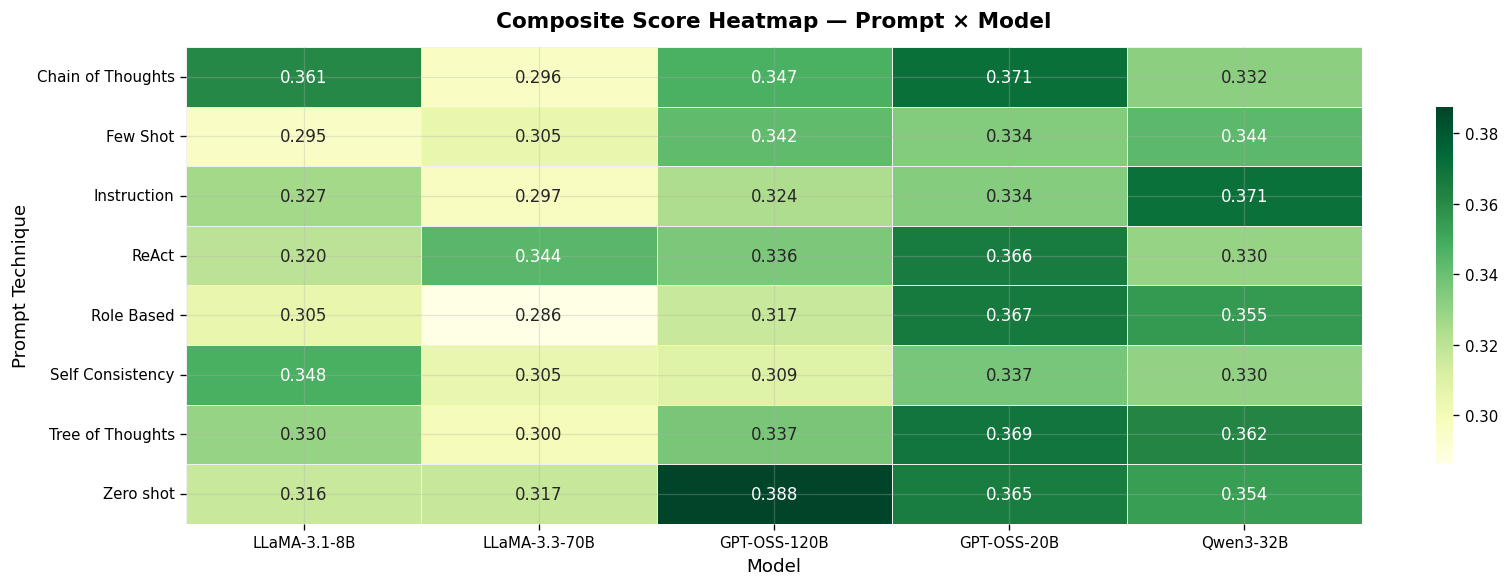

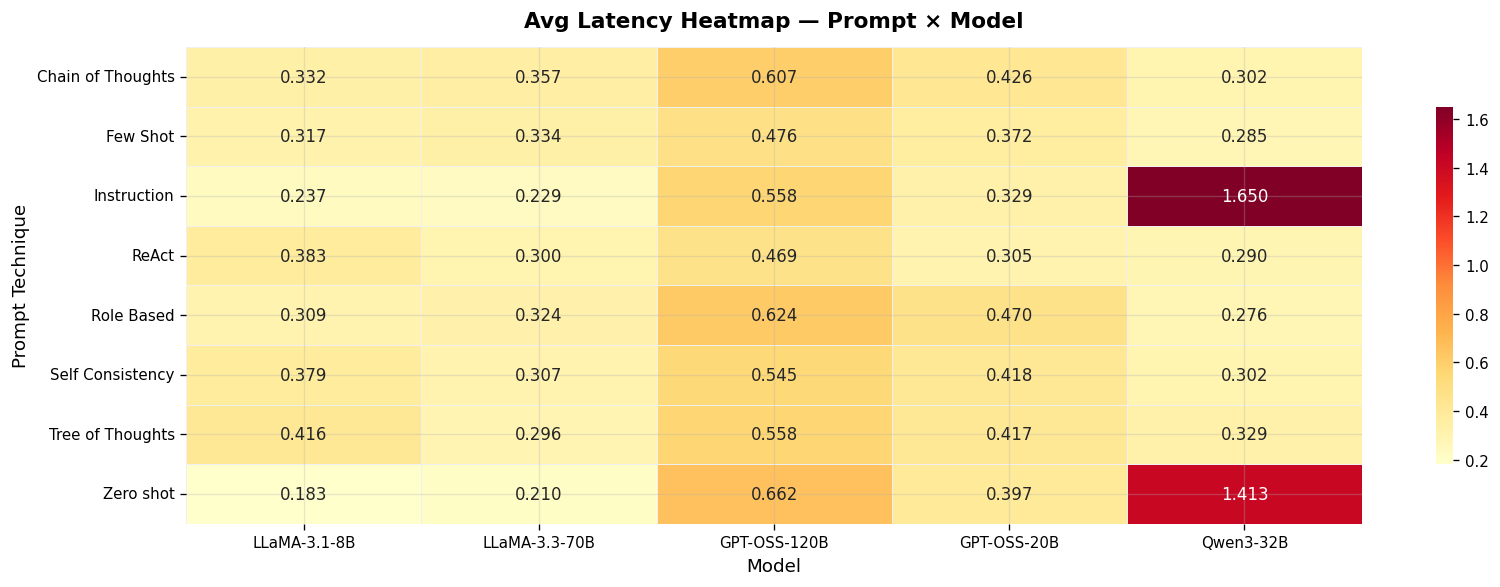

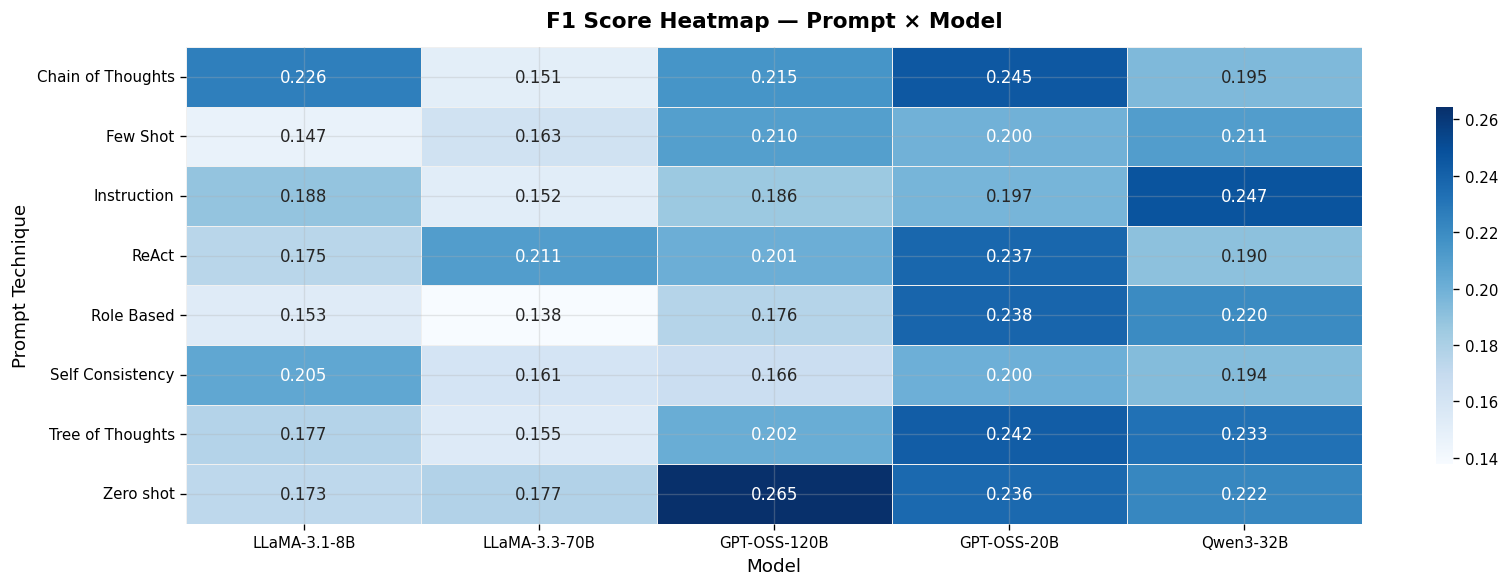

In [ ]:
def plot_heatmap(pivot_table, title, cmap, fmt=".3f", figsize=(14, 5), save_path=None):
    """Render a labelled heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot_table, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.5, linecolor="#f0f0f0", ax=ax,
                cbar_kws={"shrink": 0.75})
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Model", fontsize=11)
    ax.set_ylabel("Prompt Technique", fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


# Composite Score heatmap
comp_heat = (
    df.groupby(["Prompting", "Model"])["composite_score"]
    .mean()
    .unstack("Model")
    .reindex(columns=MODELS)
)
plot_heatmap(
    comp_heat,
    "Composite Score Heatmap — Prompt × Model",
    "YlGn",
    save_path="skills_heatmap_composite.png",
)

# Latency heatmap
lat_heat = (
    df.groupby(["Prompting", "Model"])["avg_latency_sec"]
    .mean()
    .unstack("Model")
    .reindex(columns=MODELS)
)
plot_heatmap(
    lat_heat,
    "Avg Latency Heatmap — Prompt × Model",
    "YlOrRd",
    save_path="skills_heatmap_latency.png",
)

# F1 Score heatmap
f1_heat = (
    df.groupby(["Prompting", "Model"])["avg_f1"]
    .mean()
    .unstack("Model")
    .reindex(columns=MODELS)
)
plot_heatmap(
    f1_heat,
    "F1 Score Heatmap — Prompt × Model",
    "Blues",
    save_path="skills_heatmap_f1.png",
)

## 8. Precision–Recall–F1 Triangle Plot per Prompt Technique

Skill extraction uniquely benefits from seeing Precision vs Recall trade-offs alongside F1.

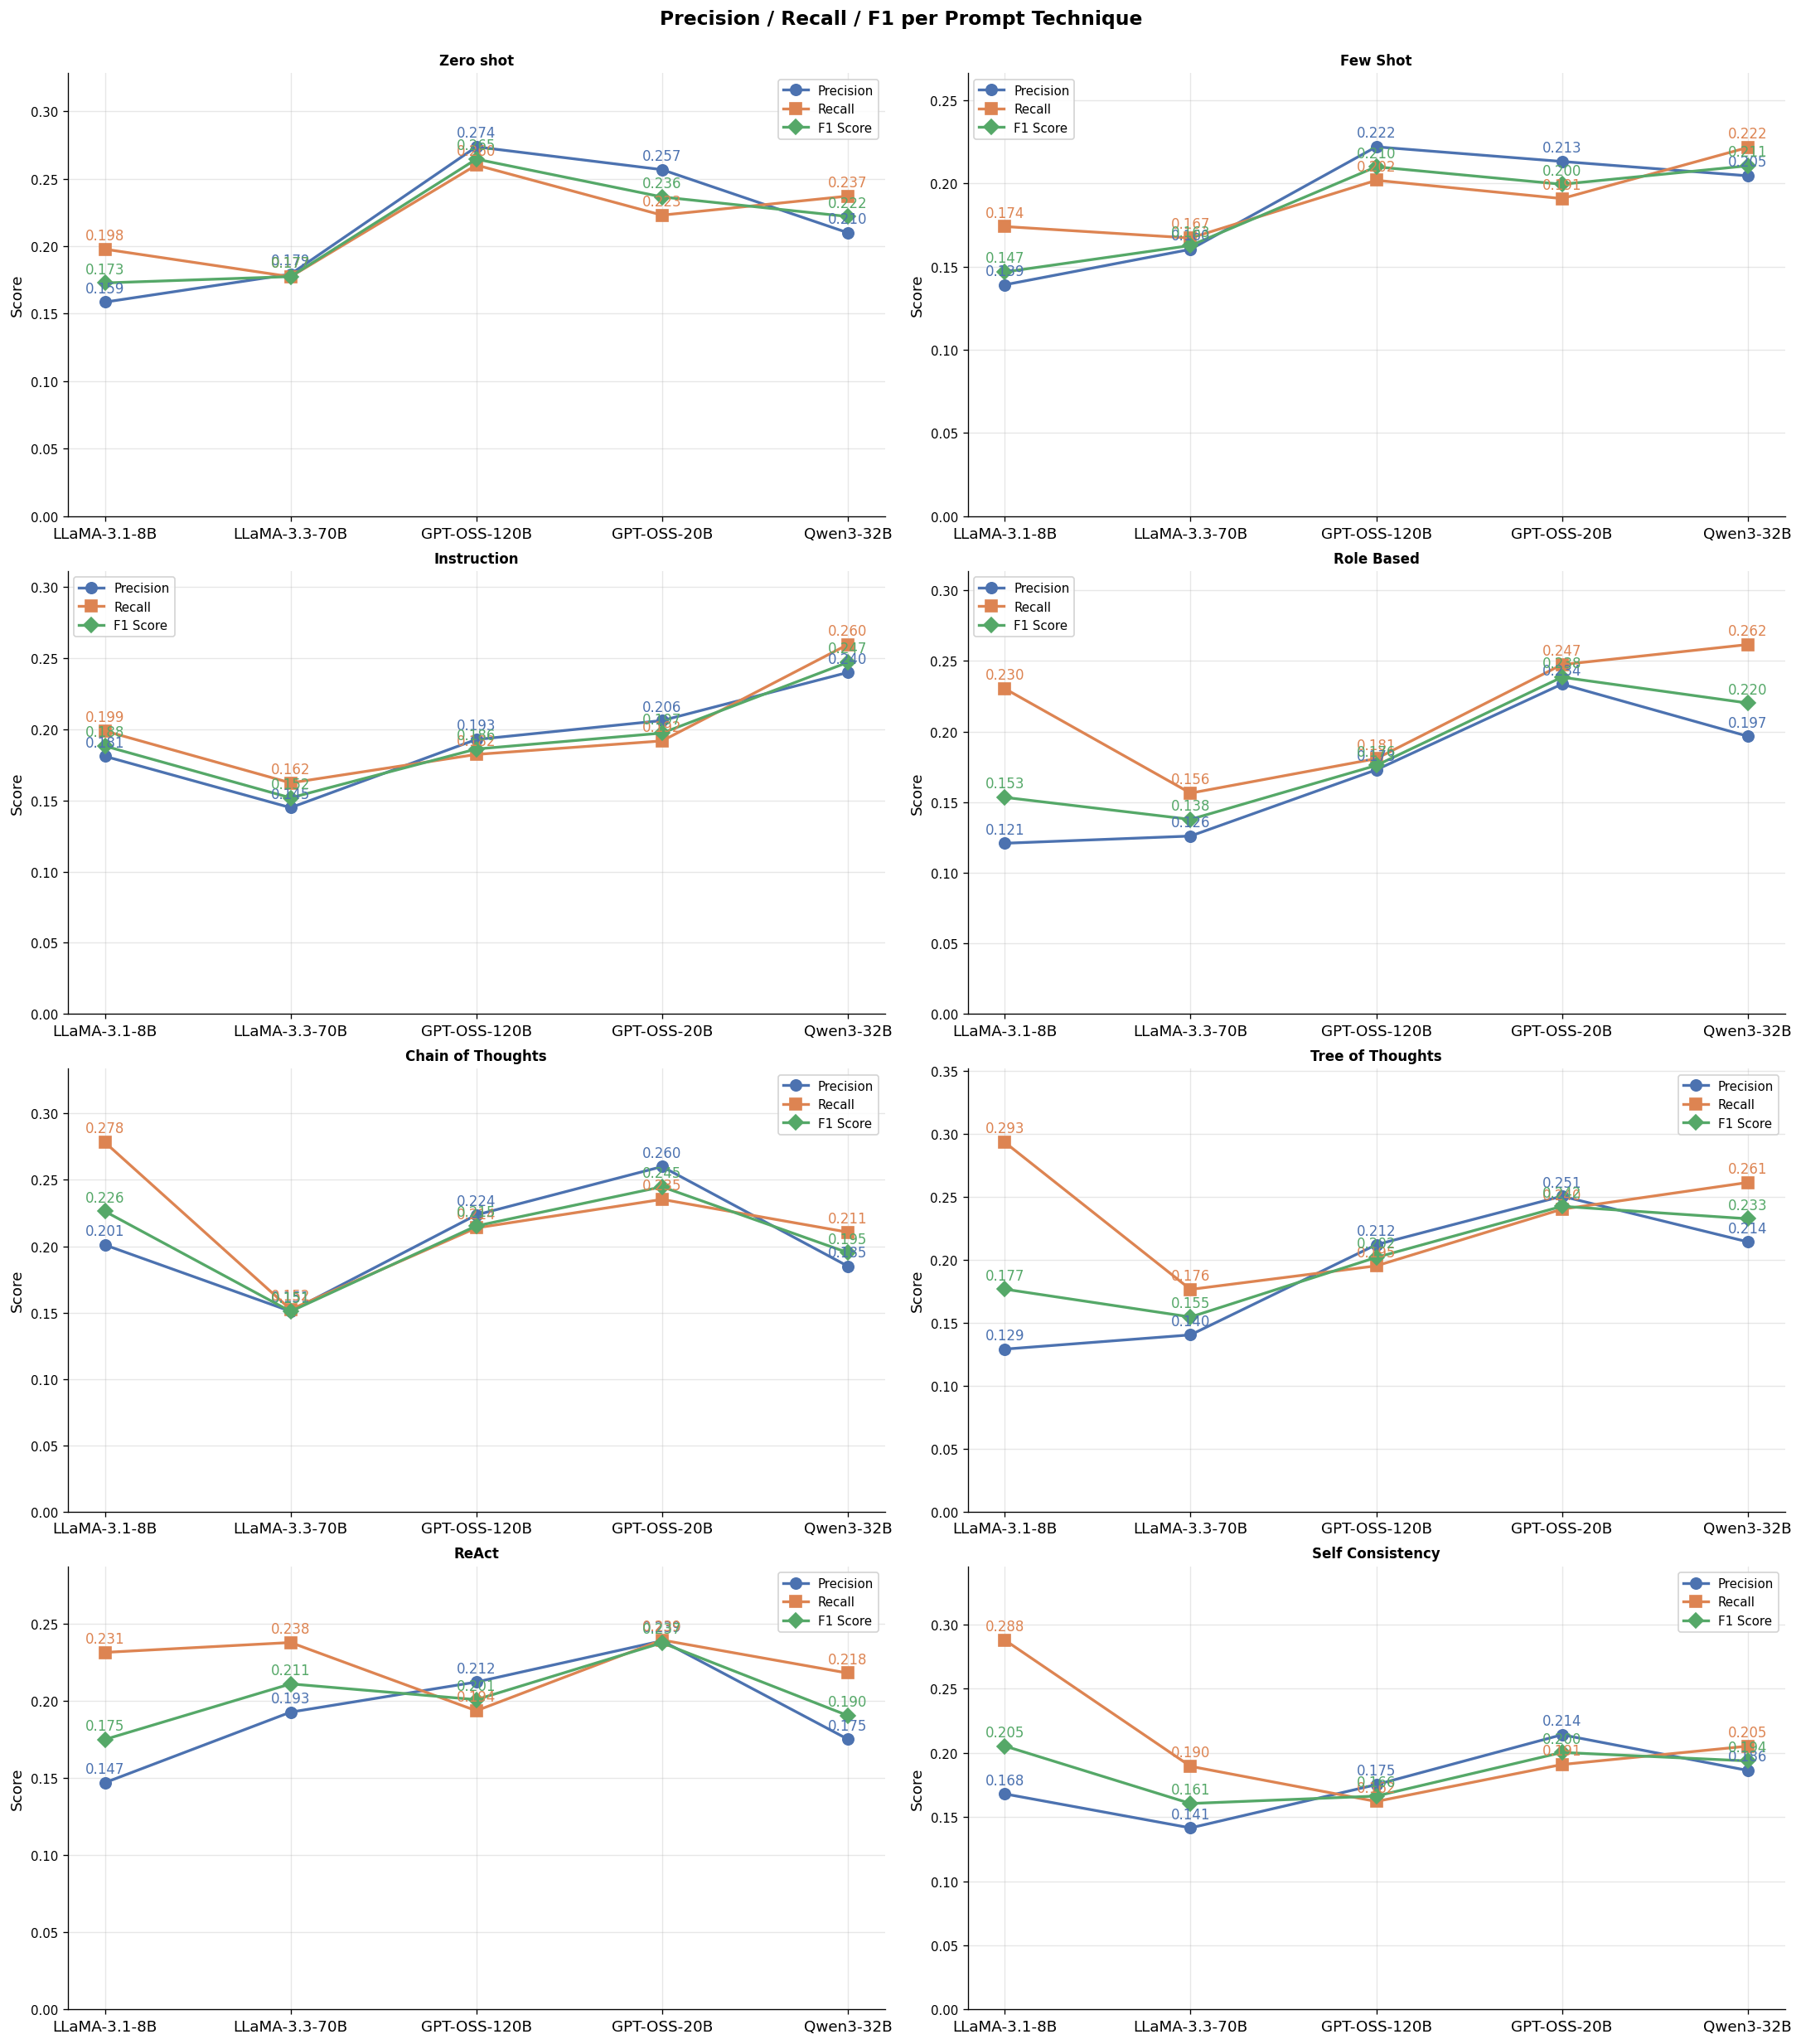

In [ ]:
n_prompts = len(PROMPTS)
n_cols = 2
n_rows = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

prf_metrics = ["avg_precision", "avg_recall", "avg_f1"]
prf_colors  = ["#4C72B0", "#DD8452", "#55A868"]
prf_labels  = ["Precision", "Recall", "F1 Score"]
prf_markers = ["o", "s", "D"]

for idx, prompt in enumerate(PROMPTS):
    ax = axes[idx]
    subset = df[df["Prompting"] == prompt]
    agg = subset.groupby("Model")[prf_metrics].mean().reindex(MODELS)
    x = np.arange(len(MODELS))

    for metric, color, label, marker in zip(prf_metrics, prf_colors, prf_labels, prf_markers):
        vals = agg[metric].values
        ax.plot(x, vals, marker=marker, color=color, label=label,
                linewidth=2, markersize=8)
        for xi, val in zip(x, vals):
            if not np.isnan(val):
                ax.annotate(f"{val:.3f}", (xi, val),
                            textcoords="offset points", xytext=(0, 7),
                            ha="center", fontsize=10, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0, agg[prf_metrics].max().max() * 1.2)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Precision / Recall / F1 per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.02)
plt.savefig("skills_prf_per_prompt.png", bbox_inches="tight")
plt.show()

## 9. Predicted vs Gold Skill Count per Prompt Technique

Shows how many skills each model predicted versus the gold standard count.

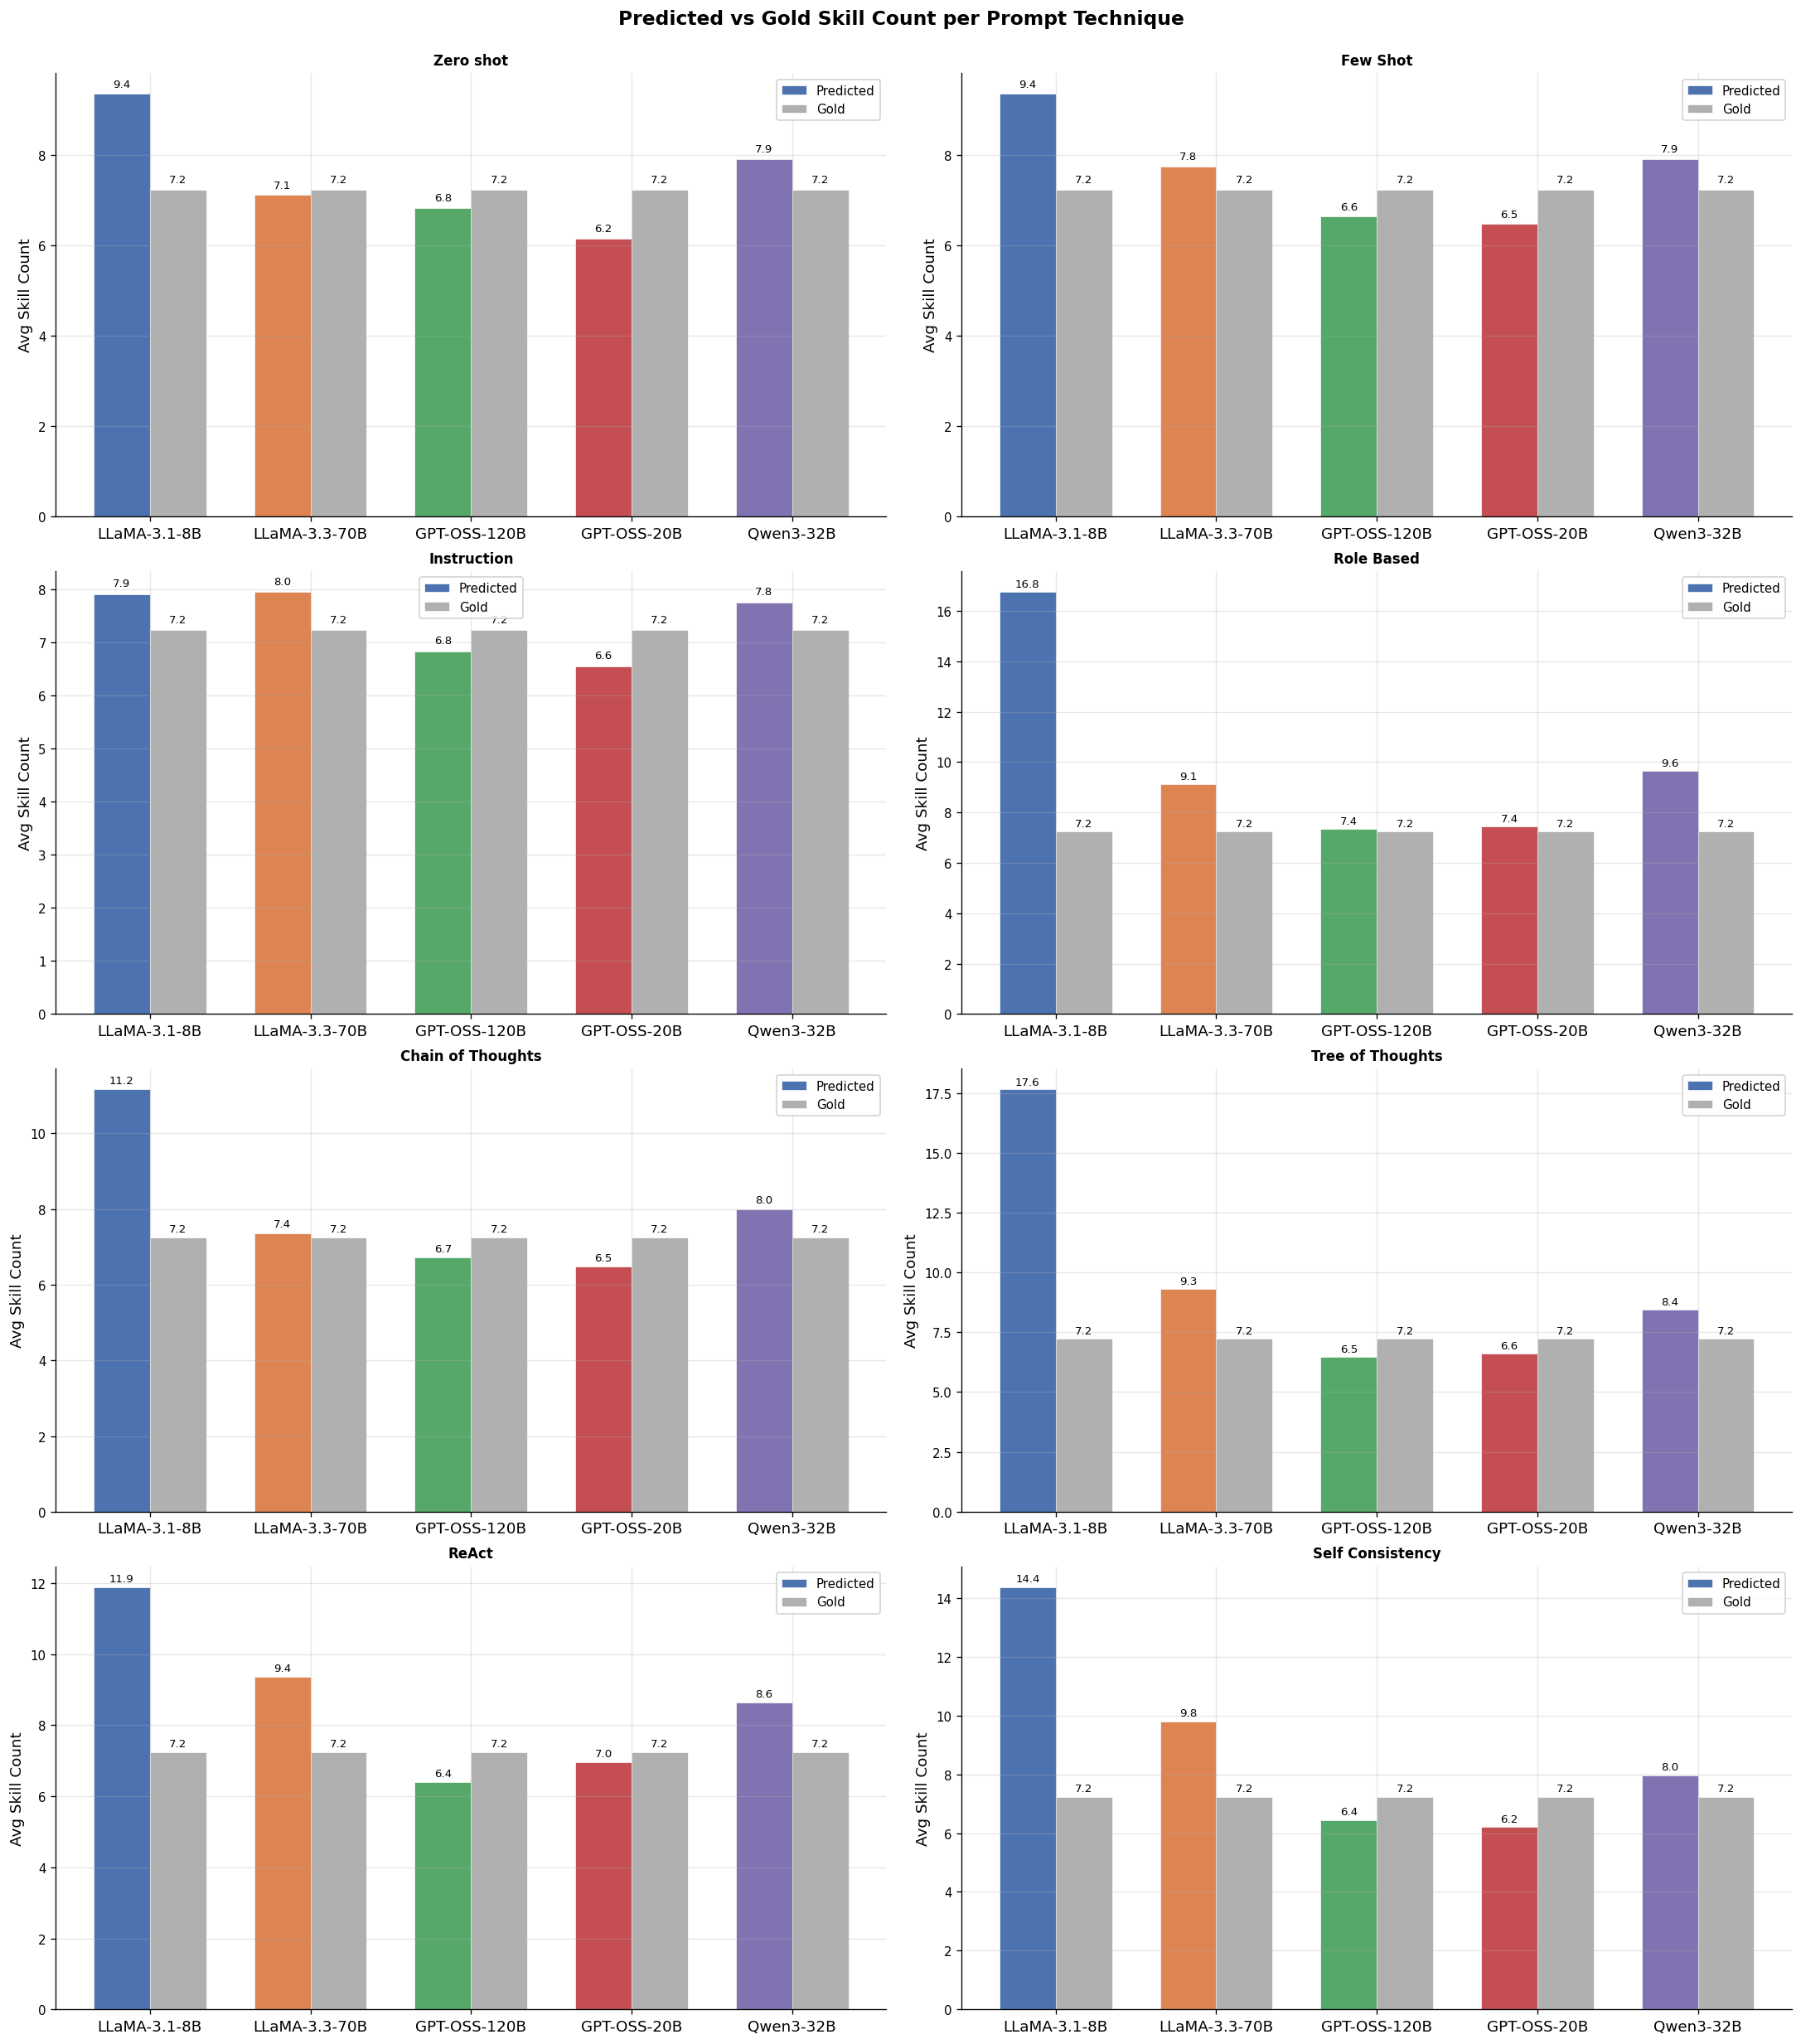

In [ ]:
n_prompts = len(PROMPTS)
n_cols = 2
n_rows = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

gold_color = "#B0B0B0"

for idx, prompt in enumerate(PROMPTS):
    ax = axes[idx]
    subset = df[df["Prompting"] == prompt]
    agg = subset.groupby("Model")[["avg_predicted_count", "avg_gold_count"]].mean().reindex(MODELS)

    x = np.arange(len(MODELS))
    bar_w = 0.35

    bars_pred = ax.bar(x - bar_w / 2, agg["avg_predicted_count"].values, width=bar_w,
                       label="Predicted", edgecolor="white", linewidth=0.4,
                       color=[MODEL_COLORS.get(m, "#888888") for m in MODELS])
    bars_gold = ax.bar(x + bar_w / 2, agg["avg_gold_count"].values, width=bar_w,
                       label="Gold", color=gold_color, edgecolor="white", linewidth=0.4)

    for bar, val in zip(bars_pred, agg["avg_predicted_count"].values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=8)
    for bar, val in zip(bars_gold, agg["avg_gold_count"].values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=11)
    ax.set_ylabel("Avg Skill Count", fontsize=11)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Predicted vs Gold Skill Count per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.02)
plt.savefig("skills_count_comparison.png", bbox_inches="tight")
plt.show()

## 10. Box Plots: Score Distribution per Model

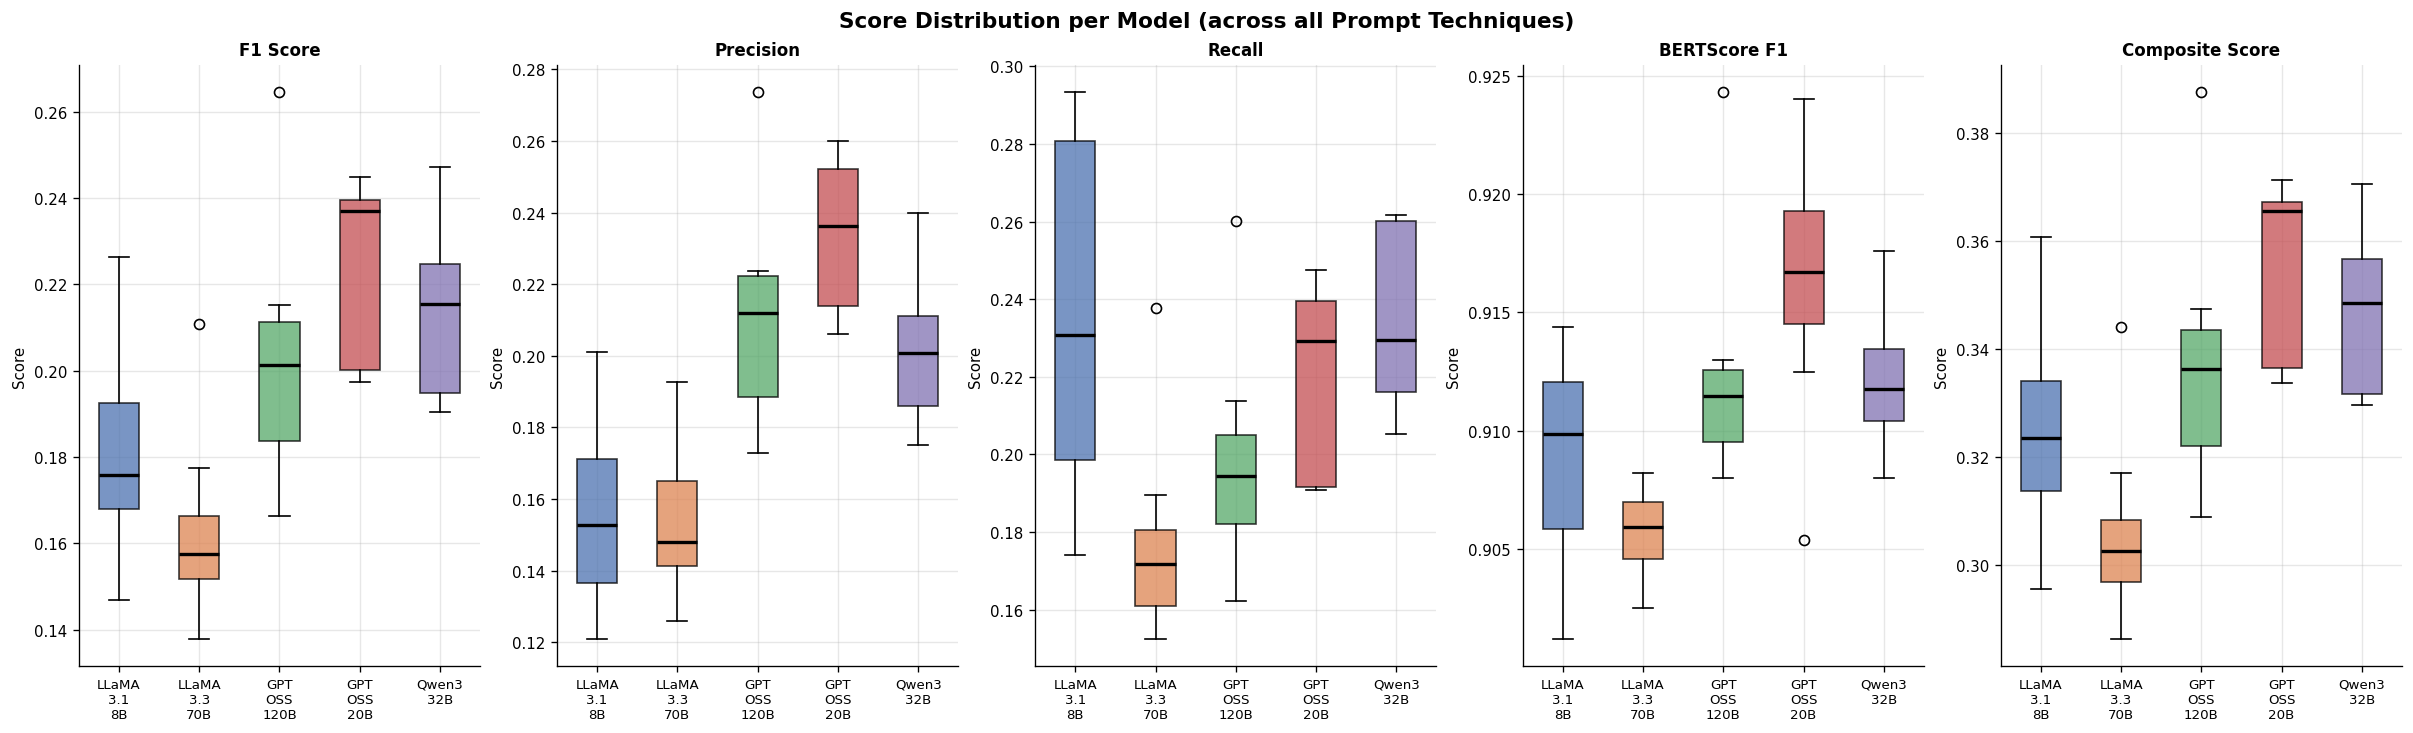

In [ ]:
box_metrics = ["avg_f1", "avg_precision", "avg_recall", "avg_bert_f1", "composite_score"]
box_labels  = [METRIC_LABELS.get(m, m) for m in box_metrics]

fig, axes = plt.subplots(1, len(box_metrics), figsize=(20, 6), constrained_layout=True)

for ax, metric, label in zip(axes, box_metrics, box_labels):
    data_by_model = [
        df[df["Model"] == model][metric].dropna().values
        for model in MODELS
    ]
    bp = ax.boxplot(data_by_model, patch_artist=True, notch=False,
                    medianprops={"color": "black", "linewidth": 2})
    for patch, model in zip(bp["boxes"], MODELS):
        patch.set_facecolor(MODEL_COLORS.get(model, "#888888"))
        patch.set_alpha(0.75)
    ax.set_xticklabels([m.replace("-", "\n") for m in MODELS], fontsize=8)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Score", fontsize=9)

fig.suptitle("Score Distribution per Model (across all Prompt Techniques)",
             fontsize=13, fontweight="bold")
plt.savefig("skills_boxplot_scores.png", bbox_inches="tight")
plt.show()

## 11. Ranking Table: Best Model per Prompt Technique

=== Best Model per Prompt × Metric ===


Metric,BERTScore F1,Composite Score,F1 Score,Precision,Recall
Prompt,,,,,
Chain of Thoughts,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,LLaMA-3.1-8B
Few Shot,Qwen3-32B,Qwen3-32B,Qwen3-32B,GPT-OSS-120B,Qwen3-32B
Instruction,GPT-OSS-20B,Qwen3-32B,Qwen3-32B,Qwen3-32B,Qwen3-32B
ReAct,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B
Role Based,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,Qwen3-32B
Self Consistency,GPT-OSS-20B,LLaMA-3.1-8B,LLaMA-3.1-8B,GPT-OSS-20B,LLaMA-3.1-8B
Tree of Thoughts,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,GPT-OSS-20B,LLaMA-3.1-8B
Zero shot,GPT-OSS-120B,GPT-OSS-120B,GPT-OSS-120B,GPT-OSS-120B,GPT-OSS-120B


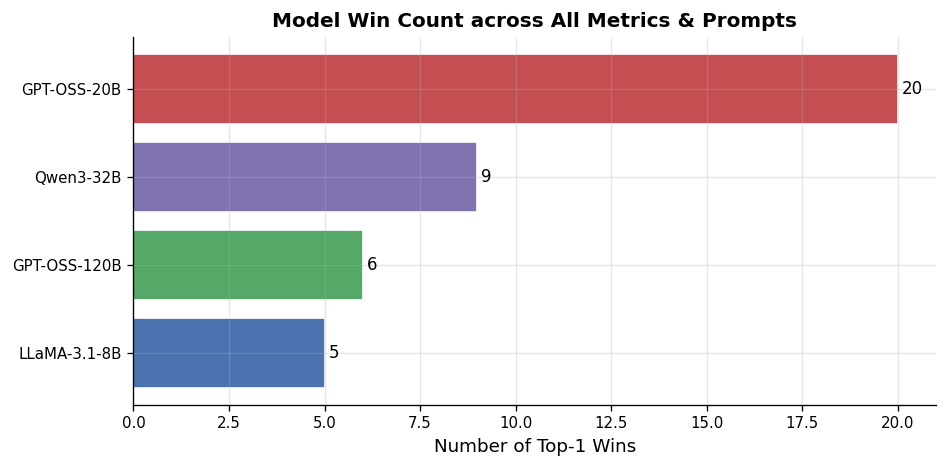

In [ ]:
rank_metrics = ["avg_f1", "avg_precision", "avg_recall", "avg_bert_f1", "composite_score"]

ranking_rows = []
for prompt in PROMPTS:
    subset = df[df["Prompting"] == prompt]
    agg = subset.groupby("Model")[rank_metrics].mean().reindex(MODELS)
    for metric in rank_metrics:
        best_model = agg[metric].idxmax()
        best_val   = agg[metric].max()
        ranking_rows.append({
            "Prompt": prompt,
            "Metric": METRIC_LABELS.get(metric, metric),
            "Best Model": best_model,
            "Score": round(best_val, 4),
        })

ranking_df = pd.DataFrame(ranking_rows)
ranking_pivot = ranking_df.pivot_table(
    index="Prompt", columns="Metric", values="Best Model", aggfunc="first"
)
print("=== Best Model per Prompt × Metric ===")
display(ranking_pivot)

# Win count per model
wins = ranking_df["Best Model"].value_counts().reset_index()
wins.columns = ["Model", "Wins"]

fig, ax = plt.subplots(figsize=(8, 4))
colors = [MODEL_COLORS.get(m, "#888888") for m in wins["Model"]]
ax.barh(wins["Model"], wins["Wins"], color=colors, edgecolor="white")
for i, (model, cnt) in wins.iterrows():
    ax.text(cnt + 0.1, i, str(cnt), va="center", fontsize=10)
ax.set_xlabel("Number of Top-1 Wins", fontsize=11)
ax.set_title("Model Win Count across All Metrics & Prompts",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("skills_model_wins.png", bbox_inches="tight")
plt.show()

## 12. Summary Statistics Table

In [ ]:
summary_metrics = ["avg_precision", "avg_recall", "avg_f1",
                   "avg_jaccard", "avg_bert_f1", "composite_score",
                   "avg_latency_sec"]

summary = (
    df.groupby(["Prompting", "Model"])[summary_metrics]
    .mean()
    .round(4)
)
summary.columns = [METRIC_LABELS.get(c, c) for c in summary.columns]
print("=== Full Summary Statistics ===")
display(summary)

=== Full Summary Statistics ===


Precision  Recall  F1 Score  Jaccard  \
Prompting         Model                                                 
Chain of Thoughts GPT-OSS-120B      0.2236  0.2138    0.2153   0.1319   
                  GPT-OSS-20B       0.2600  0.2353    0.2448   0.1517   
                  LLaMA-3.1-8B      0.2010  0.2783    0.2263   0.1451   
                  LLaMA-3.3-70B     0.1510  0.1524    0.1509   0.0898   
                  Qwen3-32B         0.1850  0.2106    0.1952   0.1226   
Few Shot          GPT-OSS-120B      0.2220  0.2019    0.2100   0.1270   
                  GPT-OSS-20B       0.2132  0.1909    0.1995   0.1255   
                  LLaMA-3.1-8B      0.1391  0.1741    0.1468   0.0859   
                  LLaMA-3.3-70B     0.1604  0.1672    0.1627   0.1023   
                  Qwen3-32B         0.2046  0.2216    0.2106   0.1263   
Instruction       GPT-OSS-120B      0.1929  0.1824    0.1862   0.1108   
                  GPT-OSS-20B       0.2062  0.1919    0.1974   0.1223   
                  LLaMA-3.1-8B      0.1811  0.1989    0.1883   0.1170   
                  LLaMA-3.3-70B     0.1450  0.1624    0.1519   0.0900   
                  Qwen3-32B         0.2400  0.2596    0.2471   0.1494   
ReAct             GPT-OSS-120B      0.2121  0.1935    0.2007   0.1210   
                  GPT-OSS-20B       0.2388  0.2393    0.2375   0.1447   
                  LLaMA-3.1-8B      0.1469  0.2313    0.1749   0.1063   
                  LLaMA-3.3-70B     0.1926  0.2377    0.2109   0.1324   
                  Qwen3-32B         0.1751  0.2179    0.1904   0.1176   
Role Based        GPT-OSS-120B      0.1729  0.1808    0.1760   0.1050   
                  GPT-OSS-20B       0.2336  0.2474    0.2385   0.1436   
                  LLaMA-3.1-8B      0.1209  0.2304    0.1534   0.0882   
                  LLaMA-3.3-70B     0.1260  0.1564    0.1378   0.0785   
                  Qwen3-32B         0.1967  0.2616    0.2202   0.1354   
Self Consistency  GPT-OSS-120B      0.1752  0.1621    0.1663   0.0983   
                  GPT-OSS-20B       0.2141  0.1909    0.2003   0.1269   
                  LLaMA-3.1-8B      0.1680  0.2879    0.2053   0.1265   
                  LLaMA-3.3-70B     0.1415  0.1895    0.1605   0.0925   
                  Qwen3-32B         0.1863  0.2052    0.1937   0.1170   
Tree of Thoughts  GPT-OSS-120B      0.2120  0.1952    0.2019   0.1232   
                  GPT-OSS-20B       0.2505  0.2402    0.2425   0.1485   
                  LLaMA-3.1-8B      0.1291  0.2933    0.1767   0.1028   
                  LLaMA-3.3-70B     0.1404  0.1765    0.1546   0.0899   
                  Qwen3-32B         0.2143  0.2614    0.2326   0.1462   
Zero shot         GPT-OSS-120B      0.2736  0.2601    0.2645   0.1663   
                  GPT-OSS-20B       0.2567  0.2230    0.2365   0.1491   
                  LLaMA-3.1-8B      0.1586  0.1978    0.1728   0.1035   
                  LLaMA-3.3-70B     0.1793  0.1774    0.1775   0.1068   
                  Qwen3-32B         0.2100  0.2371    0.2220   0.1439   

                                 BERTScore F1  Composite Score  \
Prompting         Model                                          
Chain of Thoughts GPT-OSS-120B         0.9110           0.3475   
                  GPT-OSS-20B          0.9179           0.3713   
                  LLaMA-3.1-8B         0.9123           0.3607   
                  LLaMA-3.3-70B        0.9060           0.2961   
                  Qwen3-32B            0.9101           0.3320   
Few Shot          GPT-OSS-120B         0.9090           0.3423   
                  GPT-OSS-20B          0.9054           0.3343   
                  LLaMA-3.1-8B         0.9012           0.2955   
                  LLaMA-3.3-70B        0.9046           0.3055   
                  Qwen3-32B            0.9123           0.3435   
Instruction       GPT-OSS-120B         0.9097           0.3239   
                  GPT-OSS-20B          0.9125           0.3336   
                  LLaMA-3.1-8B         0.9